# Employee Attrition Analysis

## 1. Introduction

- This project analyzes employee data to understand the factors that influence employee attrition.
- The main objective is to identify employee characteristics and workplace factors associated with employees leaving the organization.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anshika2301/hr-analytics-dataset/HR Analytics Dashboard.pbix
/kaggle/input/datasets/anshika2301/hr-analytics-dataset/HR_Analytics.csv


## 2. Import Required Libraries

In [2]:
# Import Required Libraries
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/anshika2301/hr-analytics-dataset/HR_Analytics.csv')
df

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0



## 4. Dataset Overview

The dataset contains information about employees, including:

- Demographic information
- Job-related information
- Salary information
- Work experience
- Job satisfaction
- Work-life balance
- Employee attrition

### Target Variable

**Attrition** — Indicates whether an employee has left the organization.


In [4]:
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of Rows: 1480
Number of columns: 38


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

## 5. Data Understanding

In this section, we examine:

- Number of rows and columns
- Data types
- Missing values
- Duplicate records
- Statistical summary


In [7]:
df.shape

(1480, 38)

##### The dataset has 1,480 rows and 38 columns.

In [8]:
df.dtypes

EmpID                        object
Age                           int64
AgeGroup                     object
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
SalarySlab                   object
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
PerformanceRating           

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [9]:
df.isnull().sum().sum()

np.int64(57)

In [10]:
df.duplicated().sum()

np.int64(7)


##### A total of 7 duplicate rows were identified in the dataset.

In [11]:
duplicate_rows = df[df.duplicated()]
duplicate_rows

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
655,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
1305,RM1469,49,46-55,No,Travel_Frequently,1023,Sales,2,3,Medical,...,4,80,0,17,3,2,9,6,0,8.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1480.0,36.917568,9.128559,18.0,30.00,36.0,43.00,60.0
DailyRate,1480.0,801.384459,403.126988,102.0,465.00,800.0,1157.00,1499.0
DistanceFromHome,1480.0,9.220270,8.131201,1.0,2.00,7.0,14.00,29.0
Education,1480.0,2.910811,1.023796,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1480.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1480.0,1031.860811,605.955046,1.0,493.75,1027.5,1568.25,2068.0
EnvironmentSatisfaction,1480.0,2.724324,1.092579,1.0,2.00,3.0,4.00,4.0
HourlyRate,1480.0,65.845270,20.328266,30.0,48.00,66.0,83.00,100.0
JobInvolvement,1480.0,2.729730,0.713007,1.0,2.00,3.0,3.00,4.0
JobLevel,1480.0,2.064865,1.105574,1.0,1.00,2.0,3.00,5.0


## 6. Data Cleaning

The following data-cleaning steps are performed:

- Check and handle missing values
- Check and remove duplicate records
- Identify unnecessary columns
- Check inconsistent values
- Separate numerical and categorical variables

In [14]:
df['YearsWithCurrManager']=df['YearsWithCurrManager'].fillna(df['YearsWithCurrManager'].median())

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df_cleaned = df.drop_duplicates()

In [17]:
unnecessary_columns = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df_cleaned = df_cleaned.drop(columns=unnecessary_columns)

In [18]:
df_cleaned.shape

(1473, 34)

In [19]:
# Check unique values in categorical columns

categorical_columns = df_cleaned.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


EmpID:
['RM297' 'RM302' 'RM458' ... 'RM537' 'RM880' 'RM1210']

AgeGroup:
['18-25' '26-35' '36-45' '46-55' '55+']

Attrition:
['Yes' 'No']

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel' 'TravelRarely']

Department:
['Research & Development' 'Sales' 'Human Resources']

EducationField:
['Life Sciences' 'Medical' 'Marketing' 'Technical Degree' 'Other'
 'Human Resources']

Gender:
['Male' 'Female']

JobRole:
['Laboratory Technician' 'Sales Representative' 'Research Scientist'
 'Human Resources' 'Manufacturing Director' 'Sales Executive'
 'Healthcare Representative' 'Research Director' 'Manager']

MaritalStatus:
['Single' 'Divorced' 'Married']

SalarySlab:
['Upto 5k' '5k-10k' '10k-15k' '15k+']

OverTime:
['No' 'Yes']


In [20]:
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df_cleaned[col].value_counts())


--- EmpID ---
EmpID
RM1465    2
RM1467    2
RM1466    2
RM1084    1
RM1046    1
         ..
RM657     1
RM642     1
RM638     1
RM627     1
RM940     1
Name: count, Length: 1470, dtype: int64

--- AgeGroup ---
AgeGroup
26-35    607
36-45    470
46-55    226
18-25    123
55+       47
Name: count, dtype: int64

--- Attrition ---
Attrition
No     1236
Yes     237
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        1038
Travel_Frequently     278
Non-Travel            150
TravelRarely            7
Name: count, dtype: int64

--- Department ---
Department
Research & Development    963
Sales                     447
Human Resources            63
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       606
Medical             466
Marketing           159
Technical Degree    132
Other                83
Human Resources      27
Name: count, dtype: int64

--- Gender ---
Gender
Male      884
Female    589
Name: count, dtype: int64

--- Job

In [21]:
df_cleaned['BusinessTravel']=df_cleaned['BusinessTravel'].replace({
    'TravelRarely': 'Travel_Rarely'
})
df_cleaned['BusinessTravel'].value_counts()

BusinessTravel
Travel_Rarely        1045
Travel_Frequently     278
Non-Travel            150
Name: count, dtype: int64

### Check Inconsistent Values

Categorical variables were checked for inconsistent values, spelling differences, extra spaces, and unexpected categories.

The `unique()` and `value_counts()` functions were used to identify unusual or inconsistent values.

After checking the categorical variables, inconsistent values were standardized where required to maintain data quality and ensure accurate analysis.

In [22]:
# Numerical columns
numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [23]:
# Categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['EmpID', 'AgeGroup', 'Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab', 'OverTime']


In [24]:
print("Number of Numerical Columns:", len(numerical_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numerical Columns: 23
Number of Categorical Columns: 11


#### Separate Numerical and Categorical Variables

The dataset was divided into two groups:

- **Numerical Variables:** Columns containing numerical values that can be used for mathematical and statistical analysis.
- **Categorical Variables:** Columns containing text or category-based values.

This separation helps in selecting the correct analysis and visualization methods for each type of variable.

## 7. Exploratory Data Analysis

### 7.1 Univariate Analysis

Analyze the distribution of individual variables such as:

- Age
- Monthly Income
- Daily Rate
- Job Level
- Total Working Years
- NumCompaniesWorked
- YearsAtCompany

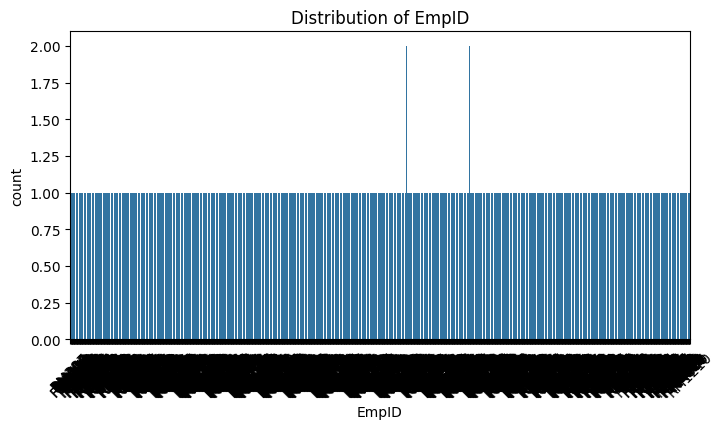

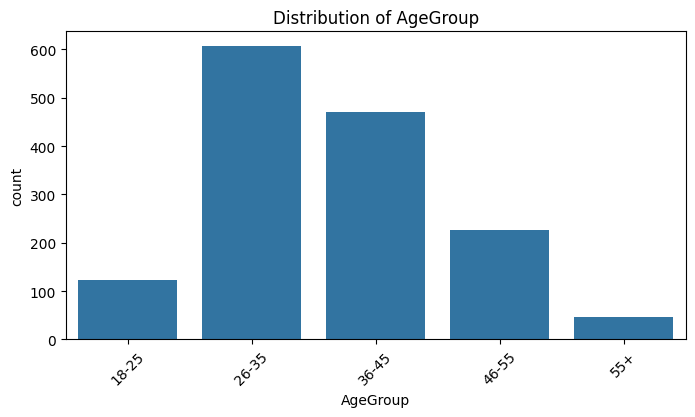

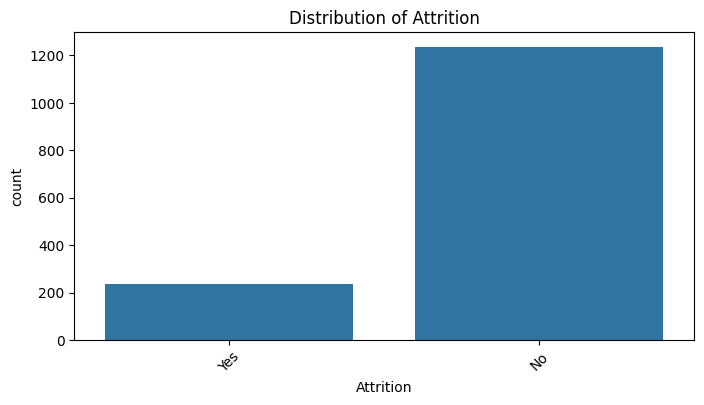

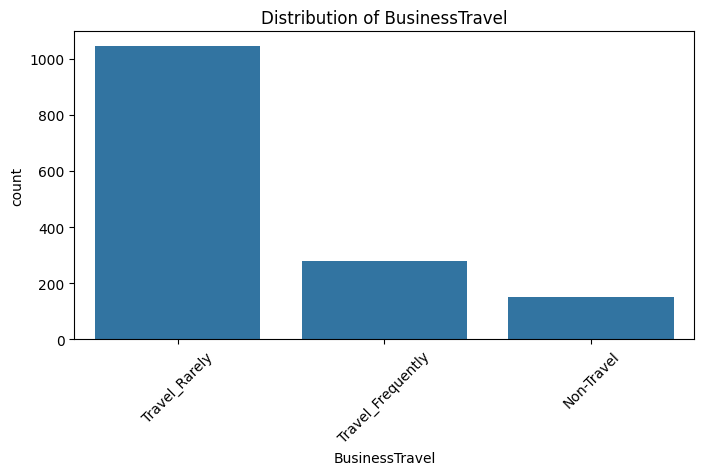

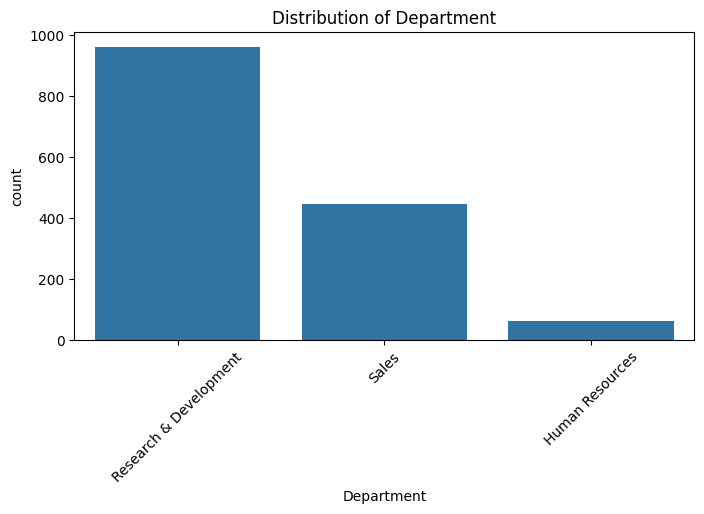

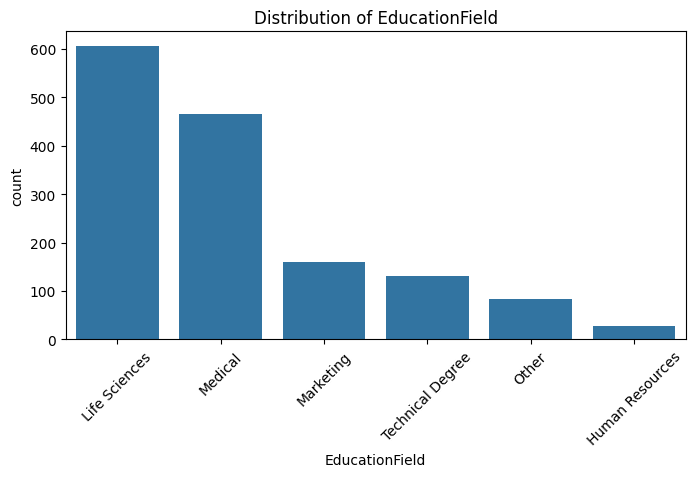

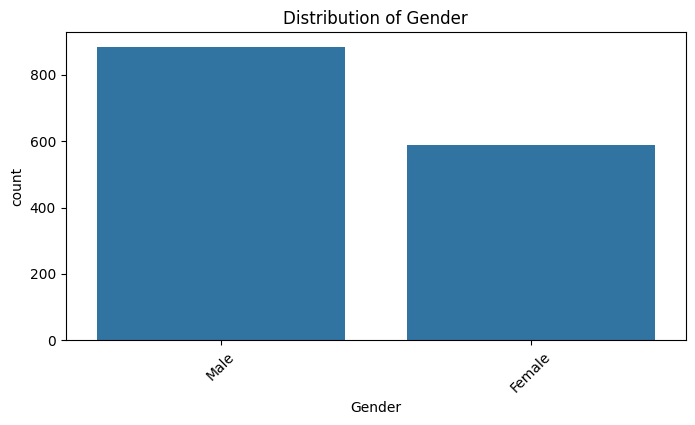

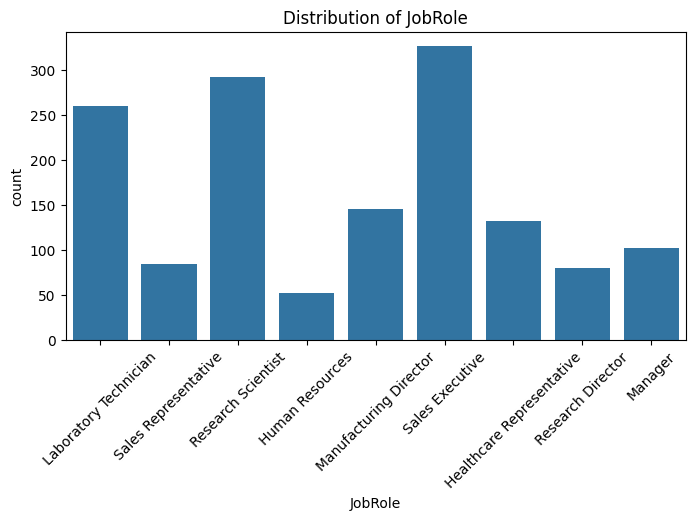

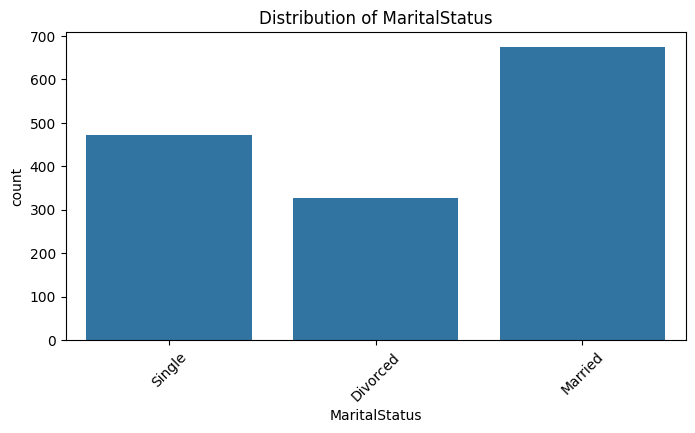

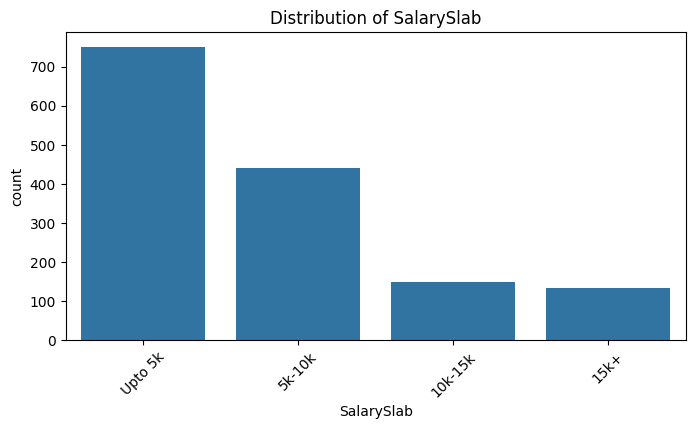

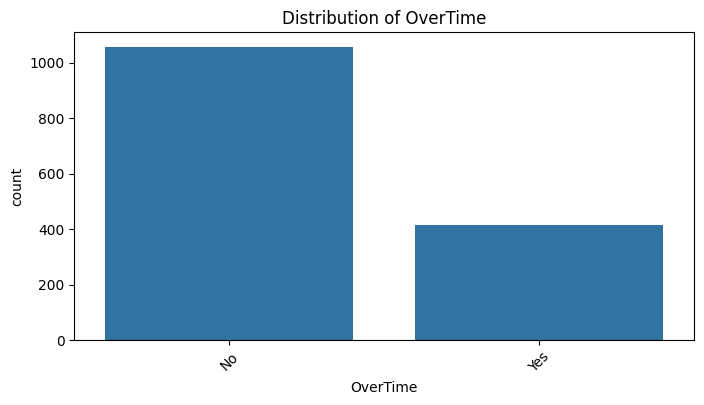

In [25]:
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_cleaned, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

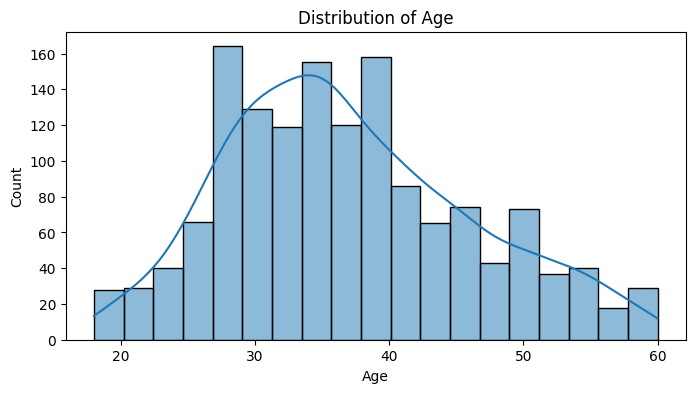

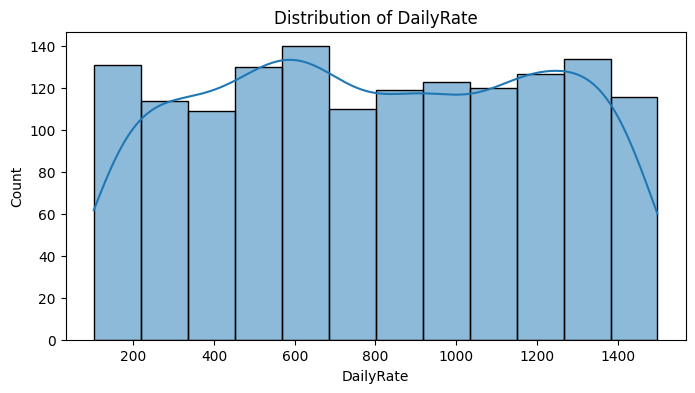

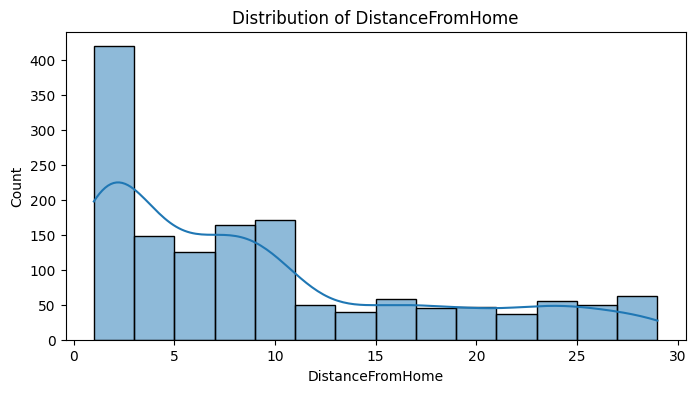

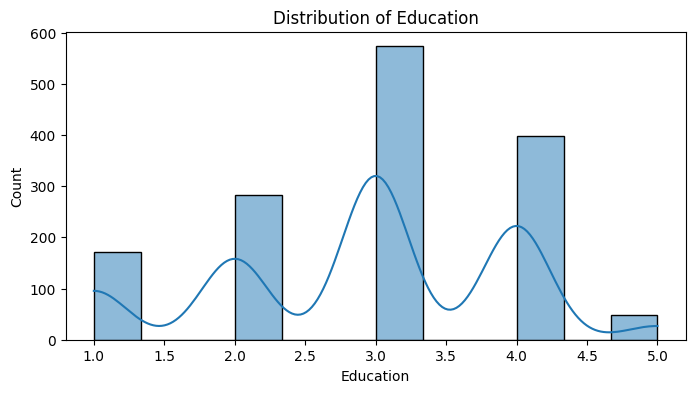

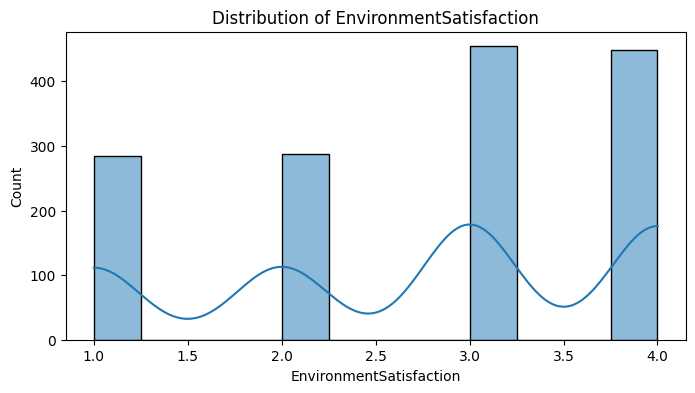

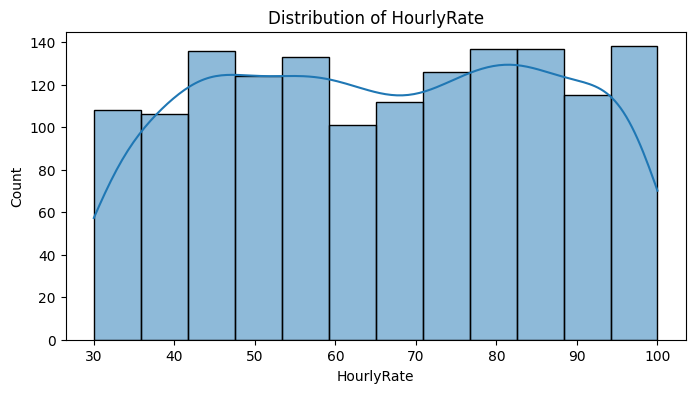

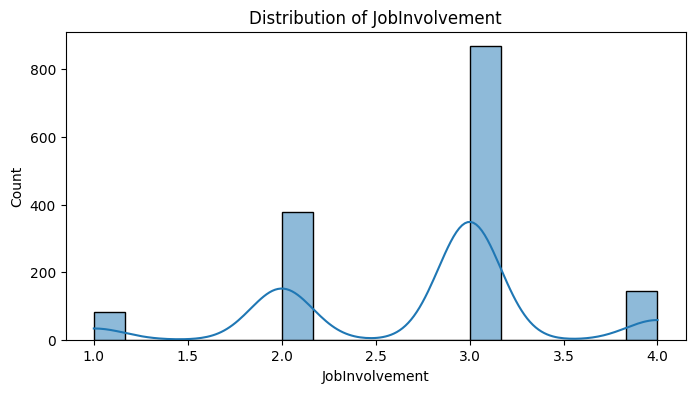

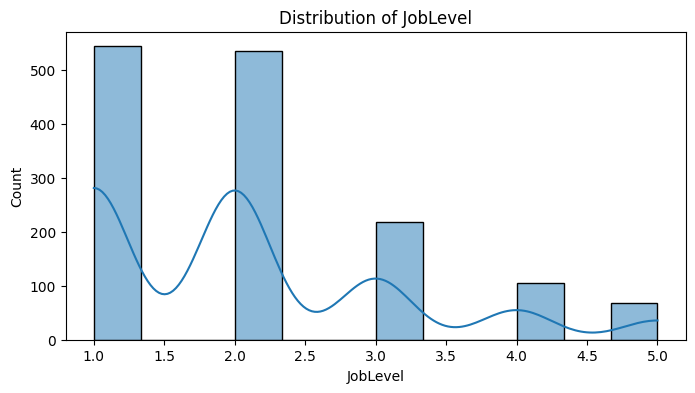

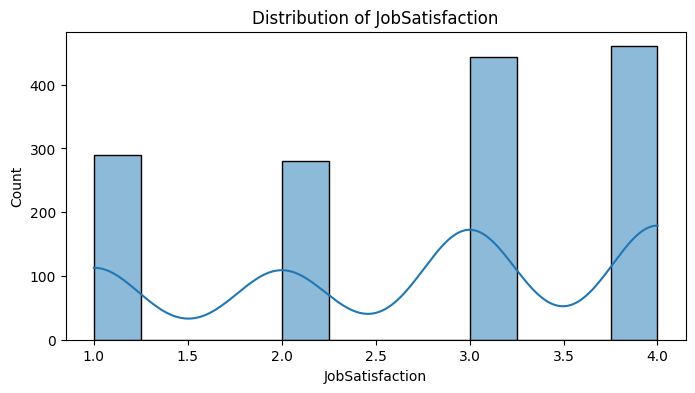

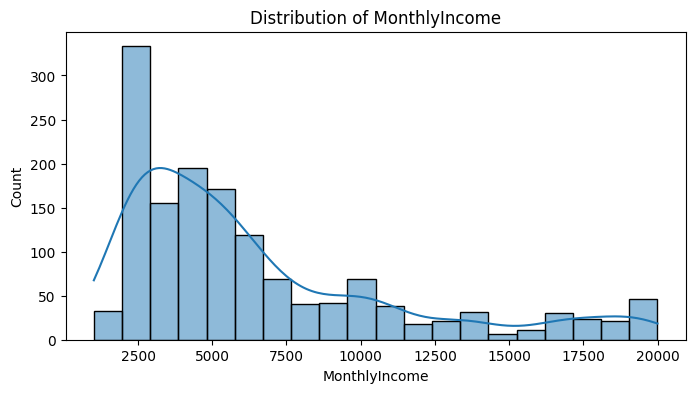

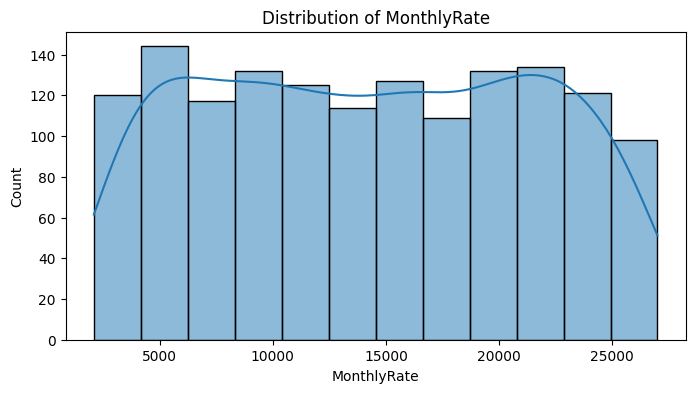

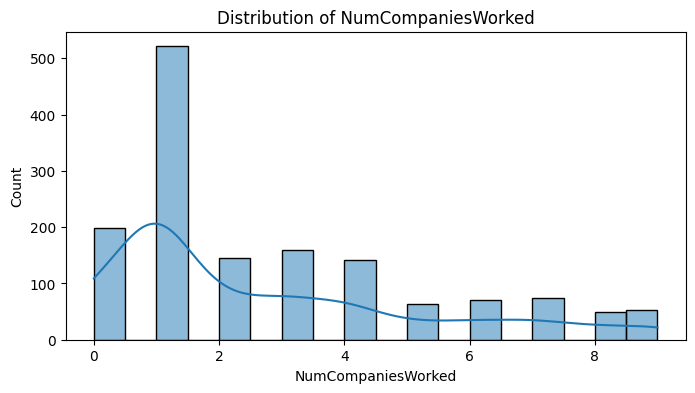

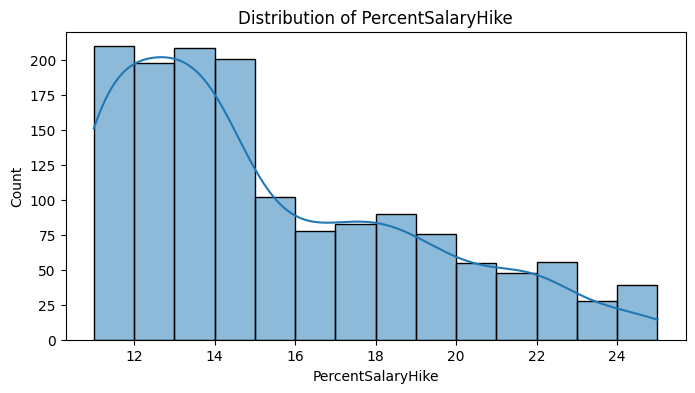

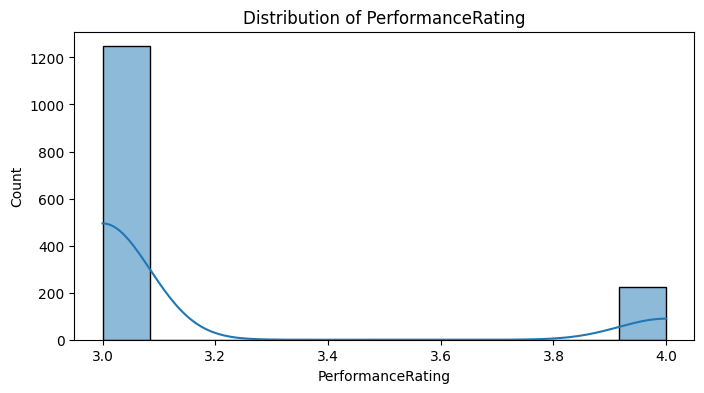

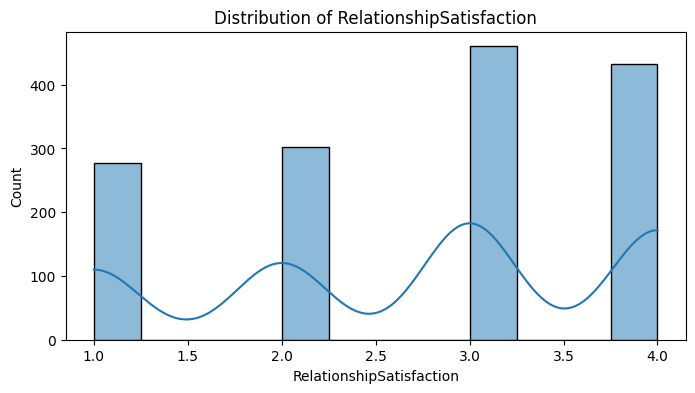

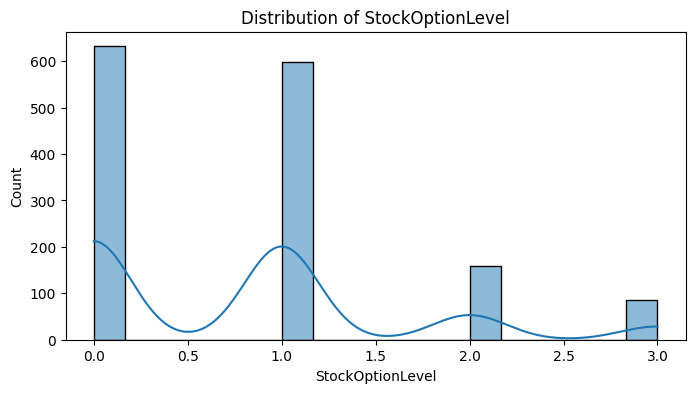

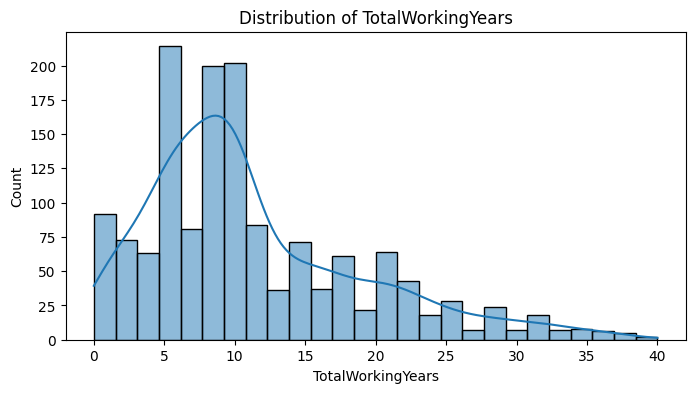

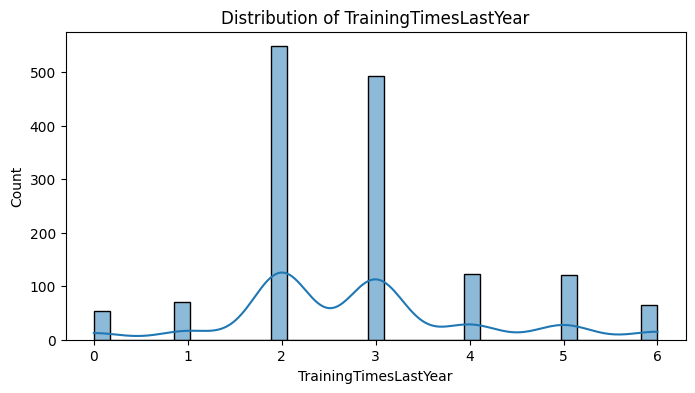

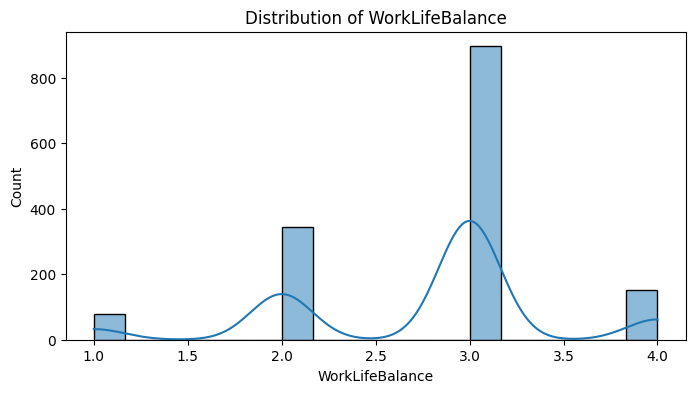

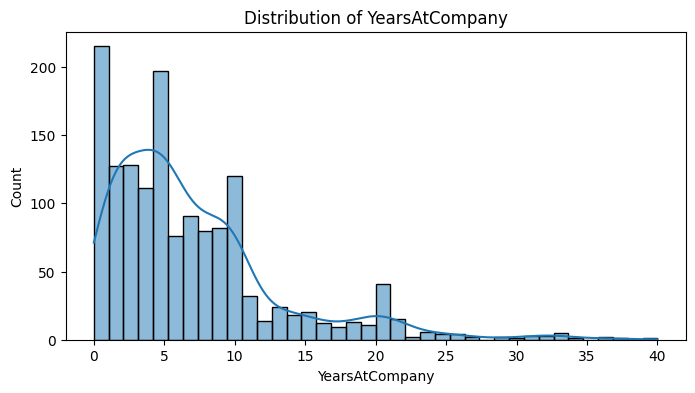

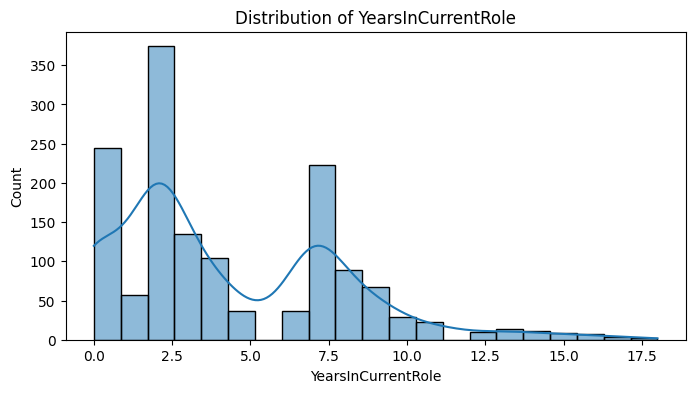

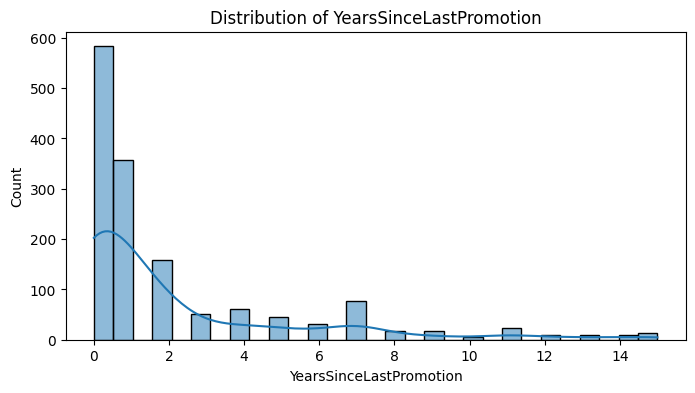

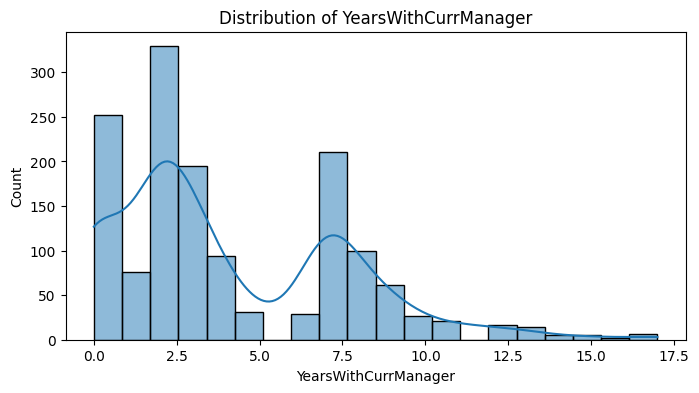

In [26]:
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [28]:
df_cleaned[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1473.0,36.917176,9.130690,18.0,30.0,36.0,43.0,60.0
DailyRate,1473.0,802.659878,403.245460,102.0,465.0,802.0,1157.0,1499.0
DistanceFromHome,1473.0,9.196877,8.107754,1.0,2.0,7.0,14.0,29.0
Education,1473.0,2.911066,1.024612,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1473.0,2.723693,1.093006,1.0,2.0,3.0,4.0,4.0
HourlyRate,1473.0,65.833673,20.350032,30.0,48.0,66.0,83.0,100.0
JobInvolvement,1473.0,2.729803,0.712115,1.0,2.0,3.0,3.0,4.0
JobLevel,1473.0,2.063815,1.106429,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,1473.0,2.728445,1.103163,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1473.0,6500.228785,4706.053923,1009.0,2911.0,4908.0,8380.0,19999.0


### Univariate Analysis

Univariate analysis is used to study one variable at a time.

For numerical variables, histograms, boxplots, and descriptive statistics were used to understand their distribution, central tendency, and outliers.

For categorical variables, count plots were used to understand the frequency of different categories.

This analysis helps us understand the overall structure and distribution of the dataset before performing further analysis.

In [29]:
Total_Employee = df_cleaned['EmpID'].count()
print("Total Employee: ",Total_Employee)

Total Employee:  1473


### 7.2 Attrition Analysis

Analyze the overall distribution of employees who stayed and employees who left.

In [30]:
# Count employees by Attrition
df_cleaned['Attrition'].value_counts()

Attrition
No     1236
Yes     237
Name: count, dtype: int64

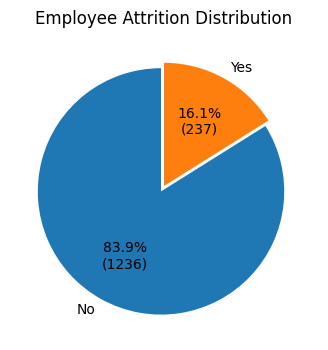

In [31]:
attrition_count = df_cleaned["Attrition"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    attrition_count.values,
    labels=attrition_count.index,
    autopct=lambda p: f"{p:.1f}%\n({int(p * sum(attrition_count) / 100)})",
    startangle=90,
    explode=[0.05, 0]
)

plt.title("Employee Attrition Distribution")
plt.show()

In [32]:
yes_data = df_cleaned[df_cleaned["Attrition"] == "Yes"]
# Create a CSV file left of employee
yes_data.to_csv("attrition_yes.csv", index=False)
yes_data.shape


(237, 34)

In [33]:
no_data = df_cleaned[df_cleaned["Attrition"] == "No"]
# Create CSV file employees did not leave the company.
no_data.to_csv("attrition_no.csv", index=False)
no_data.shape

(1236, 34)

#### Observations

- **Employees who stayed:** 1,236 employees did not leave the company.
- **Employees who left:** 237 employees left the company.
- **Total employees:** The dataset contains **1,473 employees**.
- **Attrition rate:** Approximately **16.1%** of employees left the company.
- **Business insight:** Most employees stayed, but the **237 employees who left** should be analyzed to identify the main causes of attrition.


### 7.3 Categorical Variables vs Attrition

Analyze the relationship between Attrition and:
- AgeGroup
- BusinessTravel
- Department
- EducationField
- Gender
- Job Role
- Marital Status
- SalarySlab 
- OverTime

In [34]:
df_cleaned['AgeGroup'].unique()

array(['18-25', '26-35', '36-45', '46-55', '55+'], dtype=object)

#### Number of Employees by Age Group

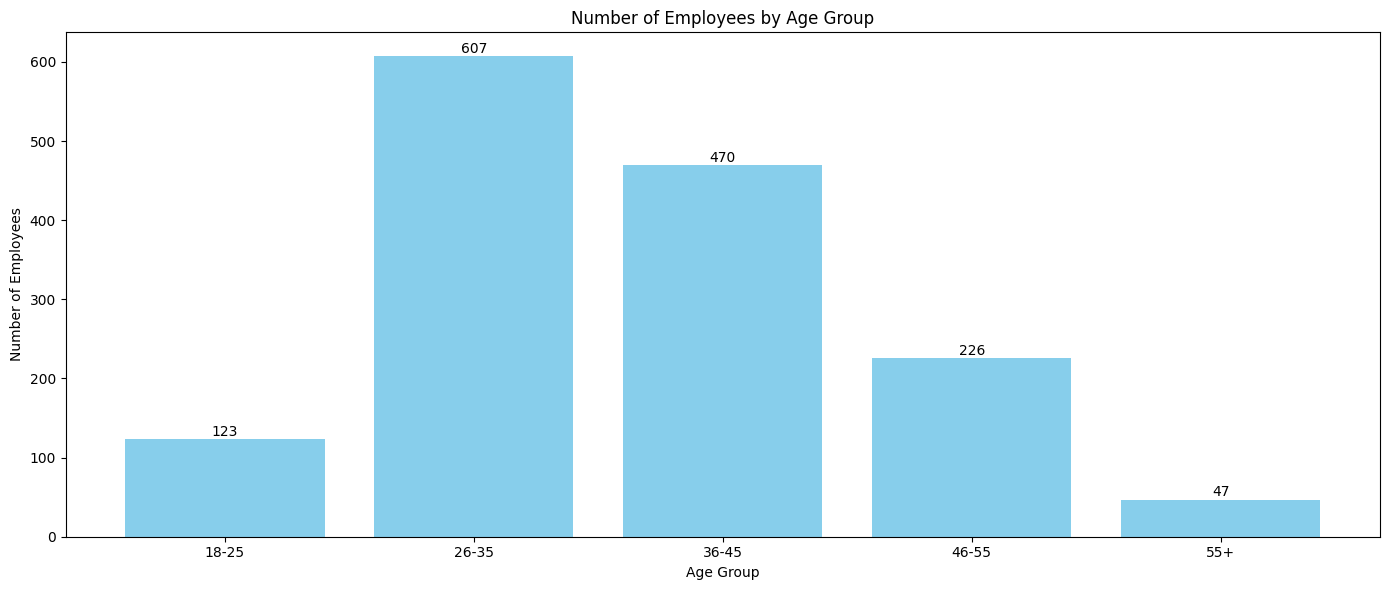

In [35]:
age_count = df_cleaned["AgeGroup"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(age_count.index, age_count.values,color="skyblue")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by Age Group")

# Show all AgeGroup labels
plt.xticks(age_count.index, rotation=0)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### Observations

- **Highest employee group:** The **26–35** age group has the most employees (**607**).
- **Second highest:** The **36–45** age group has **470 employees**.
- **18–25 group:** There are **123 employees** in this age group.
- **46–55 group:** There are **226 employees**.
- **Lowest employee group:** The **55+** age group has the fewest employees (**47**).
- **Workforce distribution:** Most employees are between **26 and 45 years old**.
- **Overall trend:** The number of employees generally **decreases as the age group increases after 26–35**.

#### Business insight
The company has a relatively young and mid-career workforce, with the majority of employees belonging to the 26–45 age range.

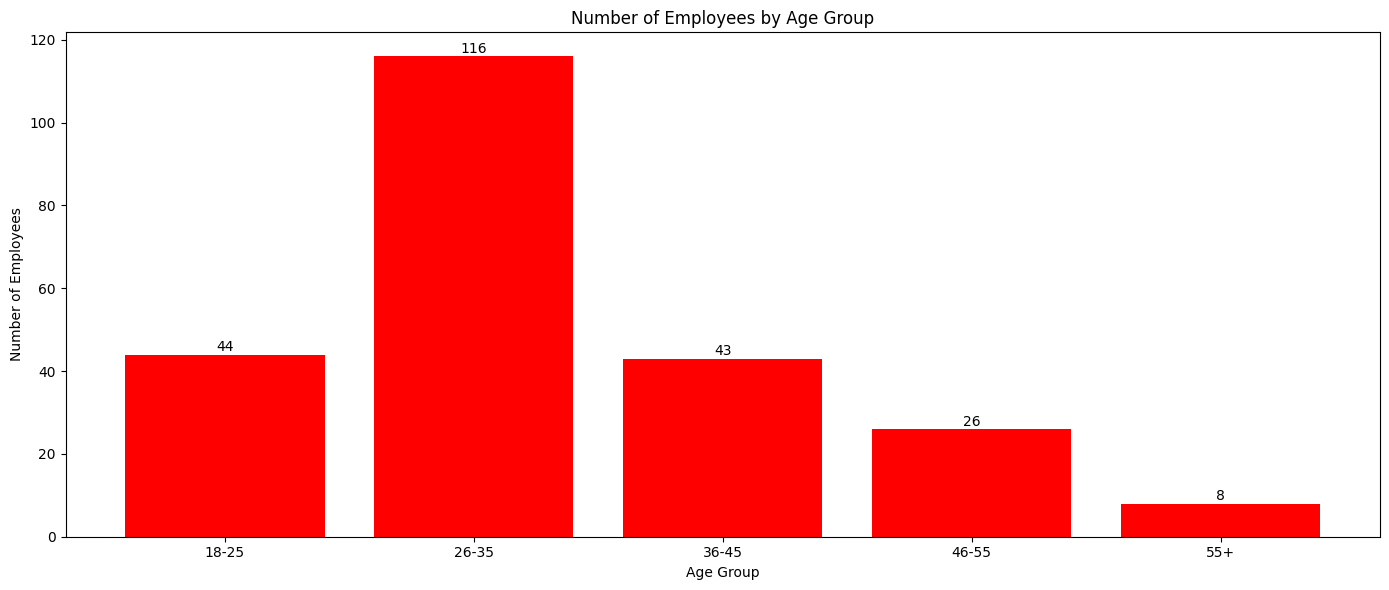

In [36]:
age_count = yes_data["AgeGroup"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(age_count.index, age_count.values,color="Red")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by Age Group")

# Show all AgeGroup labels
plt.xticks(age_count.index, rotation=0)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

####  Observations

- **Highest attrition:** The **26–35** age group has the highest number of employees who left (**116**).
- **18–25:** **44 employees** left the company.
- **36–45:** **43 employees** left the company.
- **46–55:** **26 employees** left the company.
- **Lowest attrition:** The **55+** age group has the fewest employees who left (**8**).
- **Key insight:** Most employees who left the company belong to the **26–35 age group**.

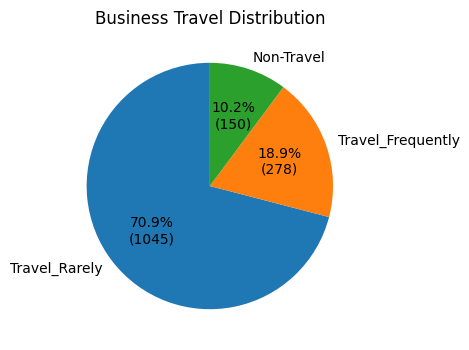

In [37]:
travel_count = df_cleaned["BusinessTravel"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    travel_count.values,
    labels=travel_count.index,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * travel_count.sum() / 100))})",
    startangle=90
)

plt.title("Business Travel Distribution")

plt.show()

In [38]:
pd.crosstab(
    df_cleaned["BusinessTravel"],
    df_cleaned["Attrition"]
)

Attrition,No,Yes
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,209,69
Travel_Rarely,889,156


#### Observations

- **Travel_Rarely:** **1,045 employees (70.9%)** travel rarely.
- **Travel_Frequently:** **278 employees (18.9%)** travel frequently.
- **Non-Travel:** **150 employees (10.2%)** do not travel for business.
- **Key insight:** Most employees (**70.9%**) travel rarely for business.
- Only **10.2%** of employees have **no business travel**.

In [39]:
df_cleaned['Department'].value_counts()

Department
Research & Development    963
Sales                     447
Human Resources            63
Name: count, dtype: int64

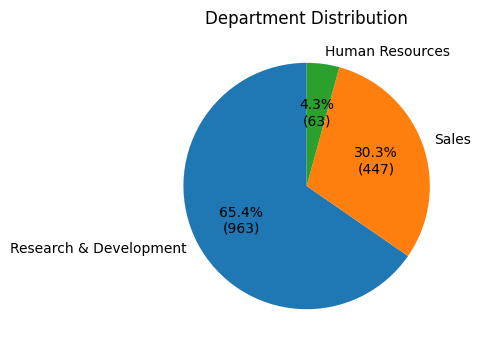

In [40]:
travel_count = df_cleaned["Department"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    travel_count.values,
    labels=travel_count.index,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * travel_count.sum() / 100))})",
    startangle=90
)

plt.title("Department Distribution")

plt.show()

In [41]:
pd.crosstab(
    df_cleaned["Department"],
    df_cleaned["Attrition"]
)

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,830,133
Sales,355,92


In [42]:
df_cleaned['EducationField'].value_counts()

EducationField
Life Sciences       606
Medical             466
Marketing           159
Technical Degree    132
Other                83
Human Resources      27
Name: count, dtype: int64

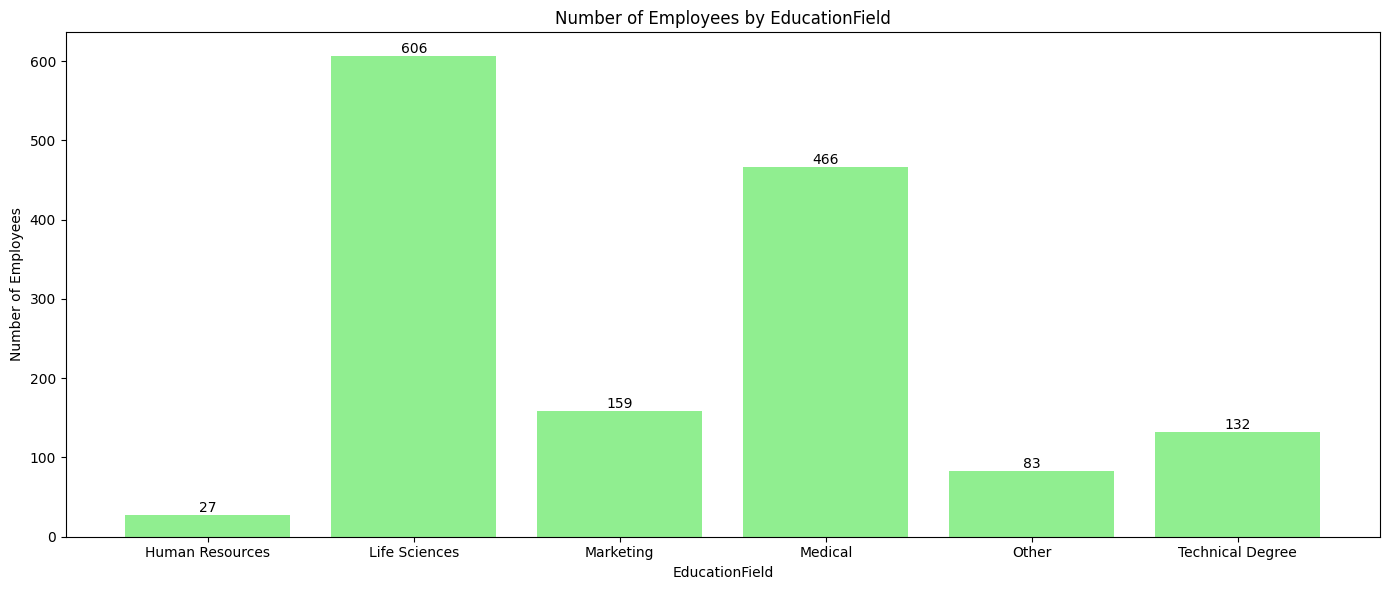

In [43]:
df_Edu_field = df_cleaned["EducationField"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(df_Edu_field.index,df_Edu_field.values,color="lightgreen")
plt.xlabel("EducationField")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by EducationField")

# Show all AgeGroup labels
plt.xticks(df_Edu_field.index, rotation=0)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### Observations

- **Life Sciences:** Has the highest number of employees (**606**).
- **Medical:** Has the second-highest number of employees (**466**).
- **Marketing:** Has **159 employees**.
- **Technical Degree:** Has **132 employees**.
- **Other:** Has **83 employees**.
- **Human Resources:** Has the lowest number of employees (**27**).
- **Key insight:** Most employees have an educational background in **Life Sciences or Medical**.

In [44]:
pd.crosstab(
    df_cleaned["EducationField"],
    df_cleaned["Attrition"]
)

Attrition,No,Yes
EducationField,,
Human Resources,20,7
Life Sciences,517,89
Marketing,124,35
Medical,403,63
Other,72,11
Technical Degree,100,32


In [45]:
df_cleaned['Gender'].value_counts()

Gender
Male      884
Female    589
Name: count, dtype: int64

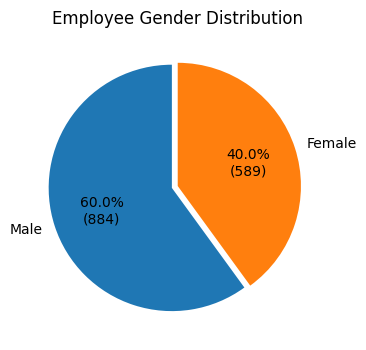

In [46]:
Gender = df_cleaned["Gender"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    Gender.values,
    labels=Gender.index,
    autopct=lambda p: f"{p:.1f}%\n({int(p * sum(Gender) / 100)})",
    startangle=90,
    explode=[0.05, 0]
)

plt.title("Employee Gender Distribution")
plt.show()

In [47]:
pd.crosstab(
    df_cleaned["Gender"],
    df_cleaned["Attrition"]
)

Attrition,No,Yes
Gender,,
Female,502,87
Male,734,150


In [48]:
pd.crosstab(
    df_cleaned["Gender"],
    df_cleaned["Age"]
    
).T

Gender,Female,Male
Age,,
18,4,4
19,4,5
20,6,5
21,6,7
22,5,11
23,1,13
24,11,15
25,6,20
26,15,25


In [49]:
pd.crosstab(
    df_cleaned["Gender"],
    df_cleaned["Department"]
    
).T

Gender,Female,Male
Department,,
Human Resources,20,43
Research & Development,379,584
Sales,190,257


In [50]:
pd.crosstab(
    df_cleaned["Gender"],
    df_cleaned["EducationField"]
    
).T

Gender,Female,Male
EducationField,,
Human Resources,8,19
Life Sciences,240,366
Marketing,69,90
Medical,190,276
Other,30,53
Technical Degree,52,80


In [51]:
df_cleaned['JobRole'].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        260
Manufacturing Director       145
Healthcare Representative    132
Manager                      102
Sales Representative          84
Research Director             80
Human Resources               52
Name: count, dtype: int64

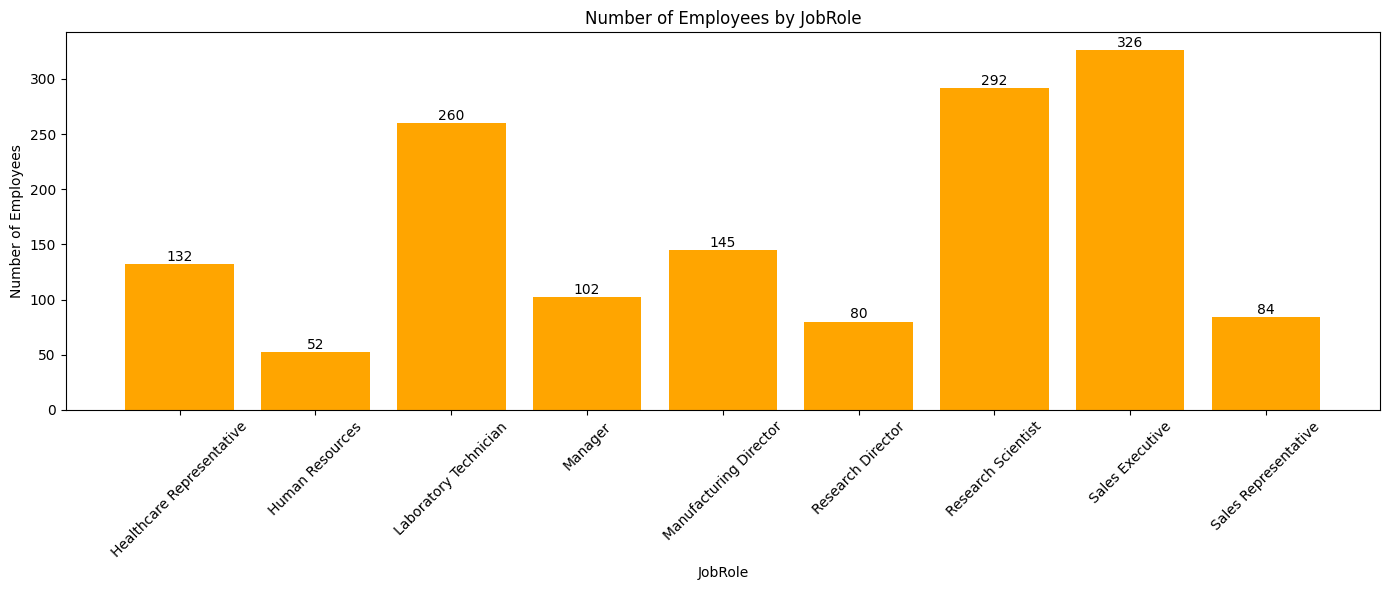

In [52]:
df_jobRole = df_cleaned["JobRole"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(df_jobRole.index,df_jobRole.values,color="Orange")
plt.xlabel("JobRole")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by JobRole")

# Show all AgeGroup labels
plt.xticks(df_jobRole.index, rotation=45)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [53]:
pd.crosstab(df_cleaned['JobRole'],
           df_cleaned['Department'
           ]).T

JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
Department,,,,,,,,,
Human Resources,0,52,0,11,0,0,0,0,0
Research & Development,132,0,260,54,145,80,292,0,0
Sales,0,0,0,37,0,0,0,326,84


In [54]:
pd.crosstab(df_cleaned['JobRole'],
           df_cleaned['EducationField'
           ]).T

JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
EducationField,,,,,,,,,
Human Resources,0,21,0,6,0,0,0,0,0
Life Sciences,60,13,119,40,71,36,133,107,27
Marketing,0,0,0,14,0,0,0,122,23
Medical,49,11,100,32,53,35,103,65,18
Other,9,3,22,5,7,4,17,13,3
Technical Degree,14,4,19,5,14,5,39,19,13


In [55]:
df_cleaned['MaritalStatus'].value_counts()

MaritalStatus
Married     675
Single      471
Divorced    327
Name: count, dtype: int64

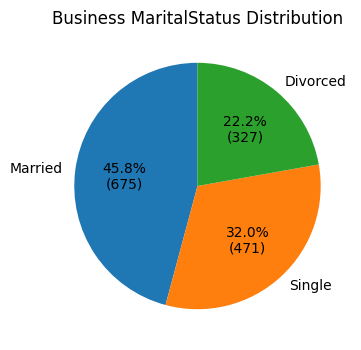

In [56]:
Marital_count = df_cleaned["MaritalStatus"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    Marital_count.values,
    labels=Marital_count.index,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * Marital_count.sum() / 100))})",
    startangle=90
)

plt.title("Business MaritalStatus Distribution")

plt.show()

#### Business Marital Status Distribution

The majority of employees are **Married**, accounting for **45.8% (675 employees)** of the workforce. **Single** employees represent **32.0% (471 employees)**, while **Divorced** employees make up **22.2% (327 employees)**.

#### Key Insight
- **Married:** 45.8% — Highest
- **Single:** 32.0%
- **Divorced:** 22.2% — Lowest

**Conclusion:** Most employees are married, while divorced employees represent the smallest group.

In [57]:
pd.crosstab(
    df_cleaned["Gender"],
    df_cleaned["MaritalStatus"]
    
).T

Gender,Female,Male
MaritalStatus,,
Divorced,117,210
Married,272,403
Single,200,271


In [58]:
pd.crosstab(
    df_cleaned["Attrition"],
    df_cleaned["MaritalStatus"]
    
).T

Attrition,No,Yes
MaritalStatus,,
Divorced,294,33
Married,591,84
Single,351,120


In [59]:
pd.crosstab(
    df_cleaned['AgeGroup'],
    df_cleaned["MaritalStatus"]+'  '+df_cleaned['Gender']
    
).T

AgeGroup,18-25,26-35,36-45,46-55,55+
col_0,,,,,
Divorced Female,4,49,40,21,3
Divorced Male,11,87,75,28,9
Married Female,11,104,89,54,14
Married Male,34,164,133,63,9
Single Female,28,86,57,25,4
Single Male,35,117,76,35,8


In [60]:
df_cleaned['SalarySlab'].value_counts()

SalarySlab
Upto 5k    751
5k-10k     441
10k-15k    148
15k+       133
Name: count, dtype: int64

In [61]:
df_cleaned['OverTime'].value_counts()

OverTime
No     1057
Yes     416
Name: count, dtype: int64

In [62]:
pd.crosstab(df_cleaned['Gender'],
           df_cleaned['OverTime']).T

Gender,Female,Male
OverTime,,
No,409,648
Yes,180,236


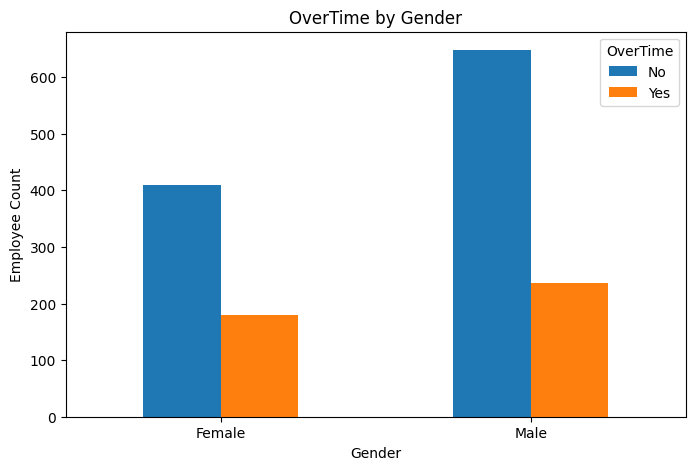

In [63]:
ct = pd.crosstab(df_cleaned['Gender'],
           df_cleaned['OverTime'])
ct.plot(kind='bar', figsize=(8, 5))

plt.title('OverTime by Gender')
plt.xlabel('Gender')
plt.ylabel('Employee Count')
plt.xticks(rotation=0)
plt.legend(title='OverTime')
plt.show()

### 7.4 Numerical Variables vs Attrition

Analyze the relationship between Attrition and:

- Age
- Daily Rate
- Distance From Home
- Education
- Environment Satisfaction
- Hourly Rate
- Job Involvement
- Job Level
- Job Satisfaction
- Monthly Income
- Monthly Rate
- Num Companies Worked
- Percent Salary Hike
- Performance Rating
- Relationship Satisfaction
- Stock Option Level
- Total Working Years
- Training Times Last Year
- Work Life Balance
- Years At Company
- Years In Current Role
- Years Since Last Promotion
- Years With Curr Manager


In [64]:
df_cleaned['Age'].unique()

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60])

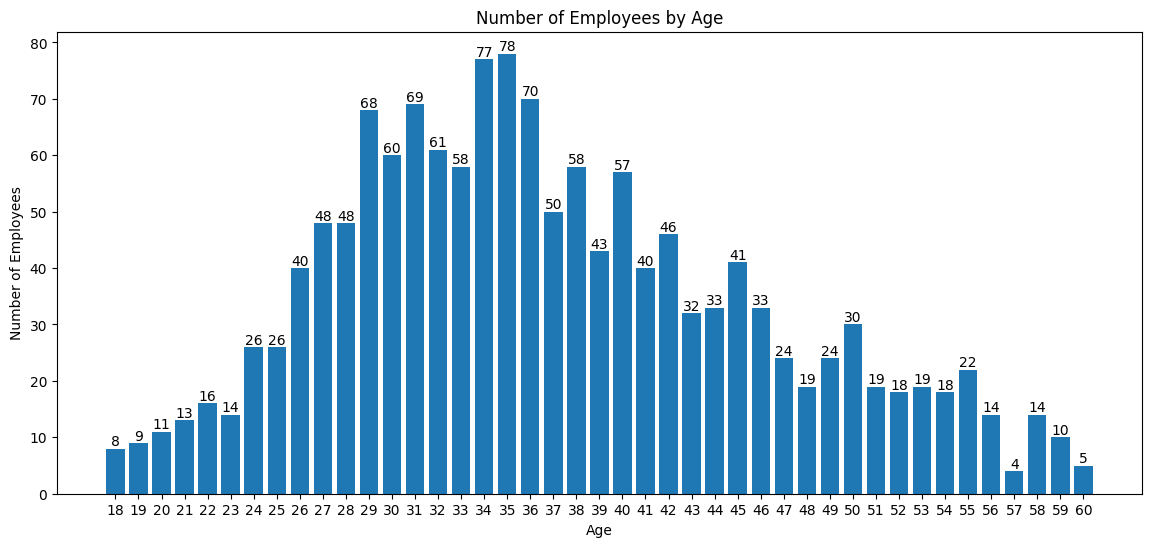

In [65]:
# Number of Employees by Age
age_count = df_cleaned["Age"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(age_count.index, age_count.values)
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by Age")
# Every age on X-axis
plt.xticks(range(df_cleaned["Age"].min(), df_cleaned["Age"].max() + 1))
# Count value on each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        int(count),
        ha="center",
        va="bottom"
    )

#### Observations
- **Age range:** Employees are between **18 and 60 years** old.
- **Highest number:** Age **35** has the most employees (**78**).
- **Age 34:** It is next with **77 employees**.
- **Age 36:** It has **70 employees**.
- **Age distribution:** Most employees are in the **late 20s to early 40s**.
- **Lower employee count:** The number of employees is **low among very young and older age groups**.
  - **Age 18:** 8 employees
  - **Age 60:** 5 employees
- **Trend:** After around **age 35**, the number of employees generally **decreases**.
#### Business insight
- The company has a mid-career workforce, with the largest employee concentration around 30–40 years old.

In [66]:
pd.crosstab(df_cleaned['Age'],
           df_cleaned['Attrition']).T

Age,18,19,20,21,22,23,24,25,26,27,...,51,52,53,54,55,56,57,58,59,60
Attrition,,,,,,,,,,,,,,,,,,,,,
No,4,3,5,7,11,10,19,20,28,45,...,17,15,17,18,19,11,4,9,10,5
Yes,4,6,6,6,5,4,7,6,12,3,...,2,3,2,0,3,3,0,5,0,0


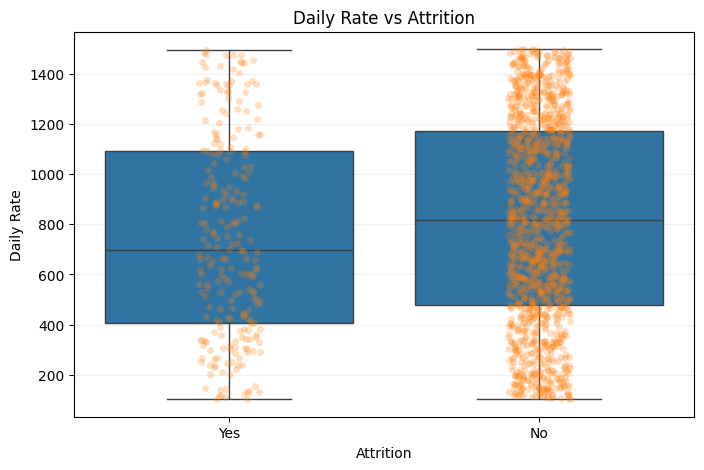

In [67]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_cleaned, x='Attrition', y='DailyRate')
sns.stripplot(
    data=df_cleaned,
    x='Attrition',
    y='DailyRate',
    alpha=0.25,
    jitter=True
)

plt.title('Daily Rate vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Daily Rate')
plt.grid(axis='y', alpha=0.2)

plt.show()

#### DailyRate vs Attrition

The box plot compares the distribution of **DailyRate** between employees who left the company and those who stayed.

#### Key Insight
- Employees who **did not leave** have a slightly higher median DailyRate than employees who left.
- However, the distributions overlap considerably.
- Therefore, **DailyRate alone does not appear to have a strong relationship with employee attrition**.

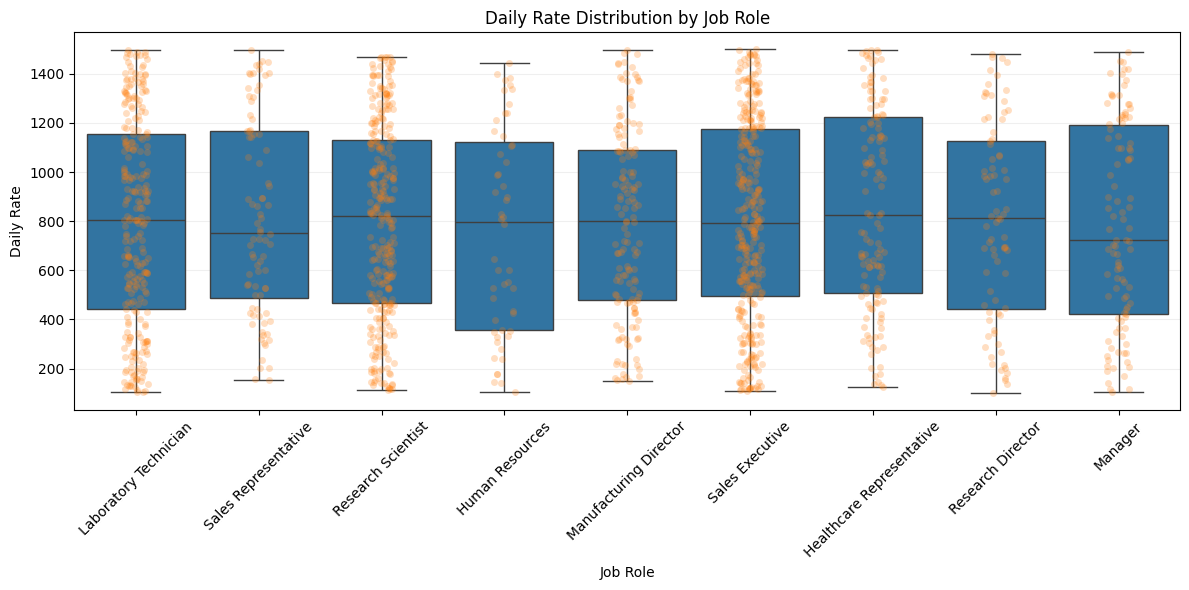

In [68]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_cleaned, x='JobRole', y='DailyRate')
sns.stripplot(
    data=df_cleaned,
    x='JobRole',
    y='DailyRate',
    alpha=0.25,
    jitter=True
)

plt.title('Daily Rate Distribution by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Daily Rate')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

#### DailyRate vs JobRole
A box plot is used to compare the distribution of **DailyRate** across different **JobRoles**.
#### Key Insight
This analysis helps identify differences in DailyRate across job roles and shows the median, spread, and variation within each role.
#### Conclusion
DailyRate varies across different job roles, but there is considerable overlap between the distributions. Therefore, JobRole alone may not strongly explain differences in DailyRate.

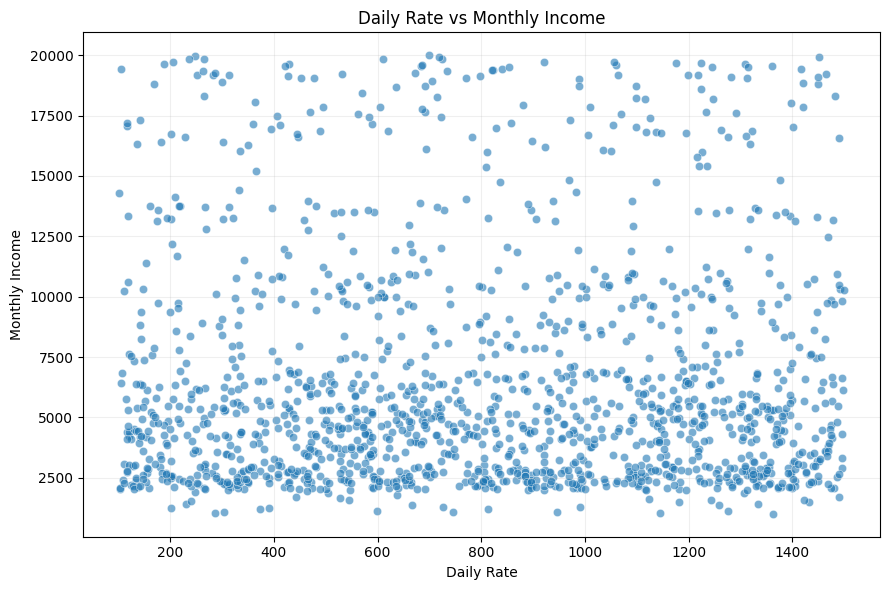

In [69]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cleaned,
    x='DailyRate',
    y='MonthlyIncome',
    alpha=0.6
)

plt.title('Daily Rate vs Monthly Income')
plt.xlabel('Daily Rate')
plt.ylabel('Monthly Income')
plt.grid(axis='both', alpha=0.2)

plt.tight_layout()
plt.show()

In [70]:
correlation = df_cleaned['DailyRate'].corr(df_cleaned['MonthlyIncome'])
print(f"Correlation: {correlation:.2f}")

Correlation: 0.01


#### DailyRate vs MonthlyIncome

A scatter plot is used to examine the relationship between **DailyRate** and **MonthlyIncome**.

#### Key Insight

The scatter plot helps determine whether employees with a higher DailyRate also tend to have a higher MonthlyIncome.
The correlation coefficient is also calculated to measure the strength and direction of the relationship.

#### Conclusion

If the points are widely scattered, there is a **weak relationship** between DailyRate and MonthlyIncome. A value close to **+1** indicates a strong positive relationship, while a value close to **0** indicates little or no linear relationship.

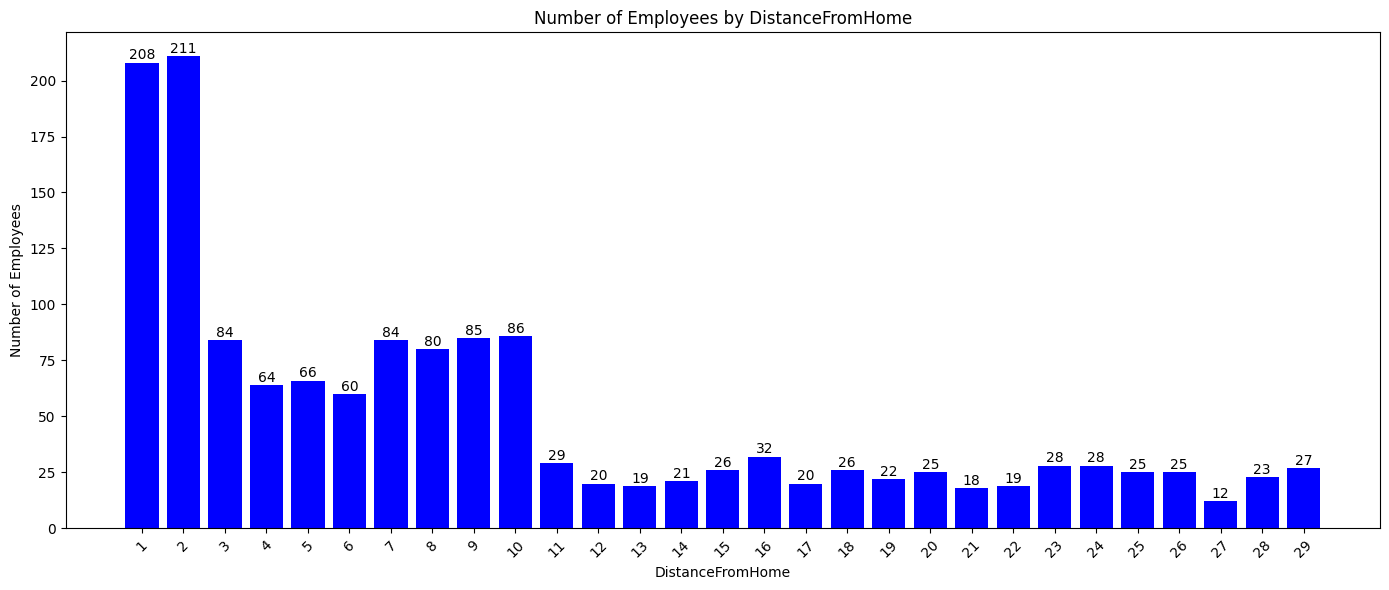

In [71]:
df_Distancefromhome = df_cleaned["DistanceFromHome"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(df_Distancefromhome.index,df_Distancefromhome.values,color="blue")
plt.xlabel("DistanceFromHome")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by DistanceFromHome")

# Show all DistanceFromHome labels
plt.xticks(df_Distancefromhome.index, rotation=45)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [72]:
pd.crosstab(df_cleaned['DistanceFromHome'],
           df_cleaned['Attrition'])

Attrition,No,Yes
DistanceFromHome,,
1,182,26
2,183,28
3,70,14
4,55,9
5,56,10
6,53,7
7,73,11
8,70,10
9,67,18


In [73]:
df_cleaned['Education'].value_counts()

Education
3    573
4    398
2    283
1    171
5     48
Name: count, dtype: int64

In [74]:
pd.crosstab(df_cleaned['Education'],
           df_cleaned['Attrition'])

Attrition,No,Yes
Education,,
1,140,31
2,239,44
3,474,99
4,340,58
5,43,5


In [75]:
mean = df_cleaned['EnvironmentSatisfaction'].mean()
print("EnvironmentSatisfaction average: ",f"{mean:.2f}")


EnvironmentSatisfaction average:  2.72


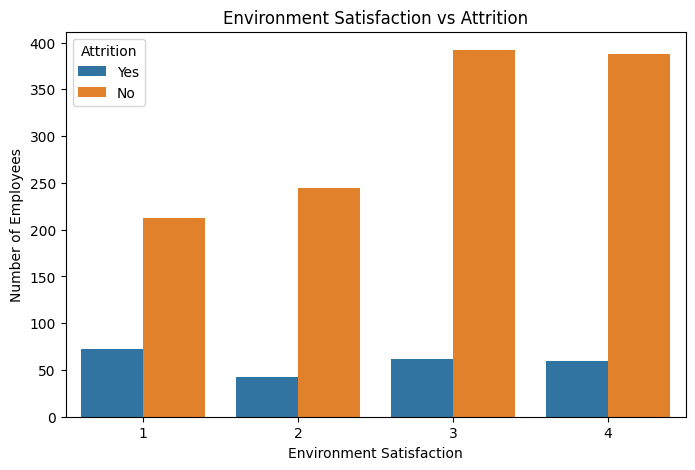

In [76]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_cleaned,
    x='EnvironmentSatisfaction',
    hue='Attrition'
)

plt.title('Environment Satisfaction vs Attrition')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Number of Employees')
plt.show()

In [77]:
df_cleaned['JobInvolvement'].value_counts()

JobInvolvement
3    868
2    377
4    145
1     83
Name: count, dtype: int64

In [78]:
pd.crosstab(df_cleaned['JobInvolvement'],
           df_cleaned['Attrition'])

Attrition,No,Yes
JobInvolvement,,
1,55,28
2,306,71
3,743,125
4,132,13


In [79]:
df_cleaned.shape

(1473, 34)

In [80]:
df_cleaned['JobLevel'].value_counts()

JobLevel
1    544
2    535
3    219
4    106
5     69
Name: count, dtype: int64

In [81]:
pd.crosstab(df_cleaned['JobLevel'],
           df_cleaned['Attrition'])

Attrition,No,Yes
JobLevel,,
1,401,143
2,483,52
3,187,32
4,101,5
5,64,5


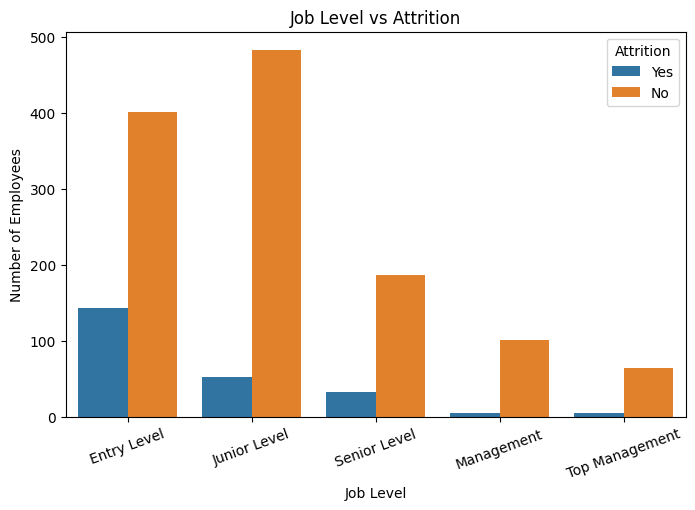

In [82]:
joblevel_map = {
    1: "Entry Level",
    2: "Junior Level",
    3: "Senior Level",
    4: "Management",
    5: "Top Management"
}

df_cleaned['JobLevelName']=df_cleaned['JobLevel'].map(joblevel_map)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_cleaned,
    x='JobLevelName',
    hue='Attrition'
)

plt.title('Job Level vs Attrition')
plt.xlabel('Job Level')
plt.ylabel('Number of Employees')
plt.xticks(rotation=20)
plt.show()

In [83]:
df_cleaned['JobSatisfaction'].value_counts()

JobSatisfaction
4    460
3    443
1    290
2    280
Name: count, dtype: int64

In [84]:
mean = df_cleaned['JobSatisfaction'].mean()
print("JobSatisfaction average: ",f"{mean:.2f}")

JobSatisfaction average:  2.73


In [85]:
pd.crosstab(df_cleaned['JobSatisfaction'],
           df_cleaned['Attrition'])

Attrition,No,Yes
JobSatisfaction,,
1,224,66
2,234,46
3,370,73
4,408,52


In [86]:
df_cleaned['MonthlyIncome'].value_counts()

MonthlyIncome
2342    4
2610    3
3452    3
2451    3
5562    3
       ..
6755    1
9439    1
2339    1
6306    1
5380    1
Name: count, Length: 1349, dtype: int64

In [87]:
df_cleaned['MonthlyIncome'].describe()

count     1473.000000
mean      6500.228785
std       4706.053923
min       1009.000000
25%       2911.000000
50%       4908.000000
75%       8380.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

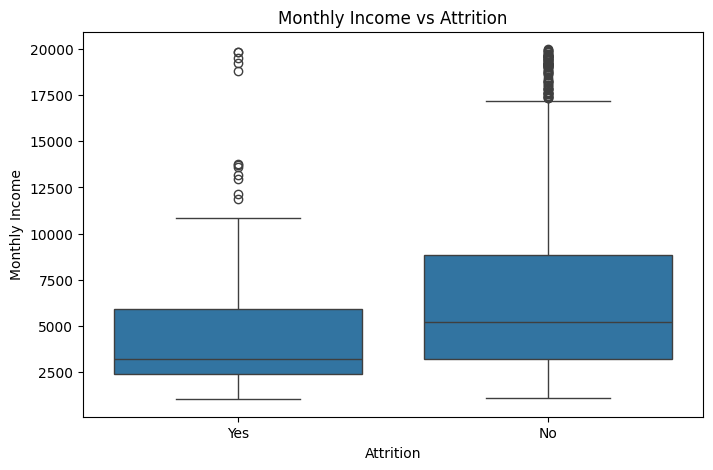

In [88]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

In [89]:
Q1 = df_cleaned['MonthlyIncome'].quantile(0.25)
Q3 = df_cleaned['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_cleaned[
    (df_cleaned['MonthlyIncome'] < lower) |
    (df_cleaned['MonthlyIncome'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 114


In [90]:
df_cleaned['MonthlyRate'].value_counts()

MonthlyRate
4223     3
9150     3
12355    2
2125     2
21457    2
        ..
7331     1
14947    1
11135    1
13554    1
15624    1
Name: count, Length: 1427, dtype: int64

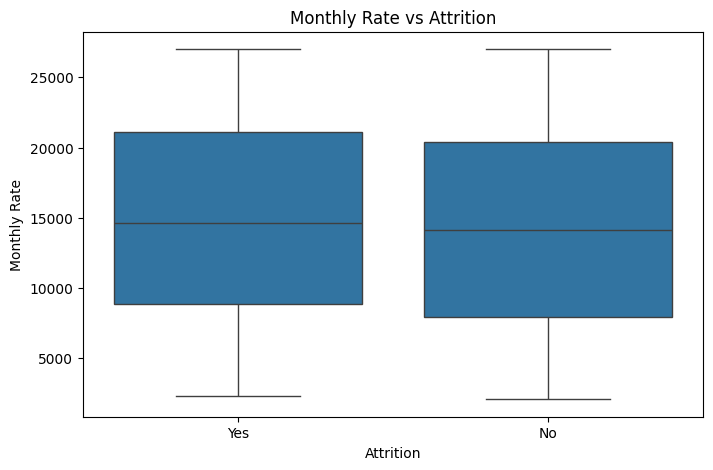

In [91]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='Attrition', y='MonthlyRate')
plt.title('Monthly Rate vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Rate')
plt.show()

In [92]:
df_cleaned['HourlyRate'].value_counts()

HourlyRate
66    29
42    29
98    28
84    28
48    28
      ..
31    15
68    14
53    14
38    13
34    12
Name: count, Length: 71, dtype: int64

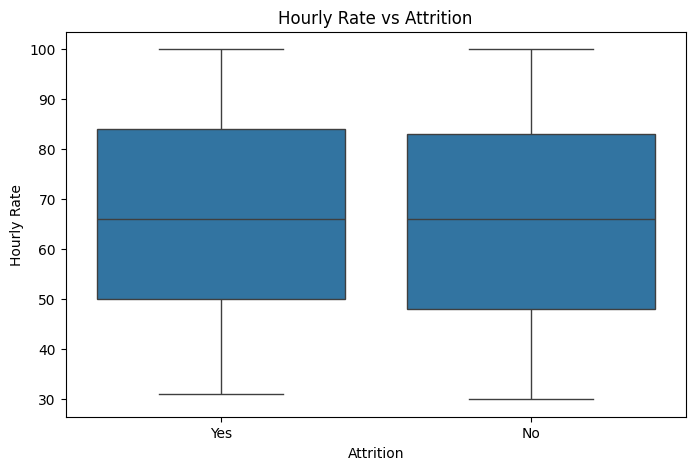

In [93]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='Attrition', y='HourlyRate')
plt.title('Hourly Rate vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Hourly Rate')
plt.show()

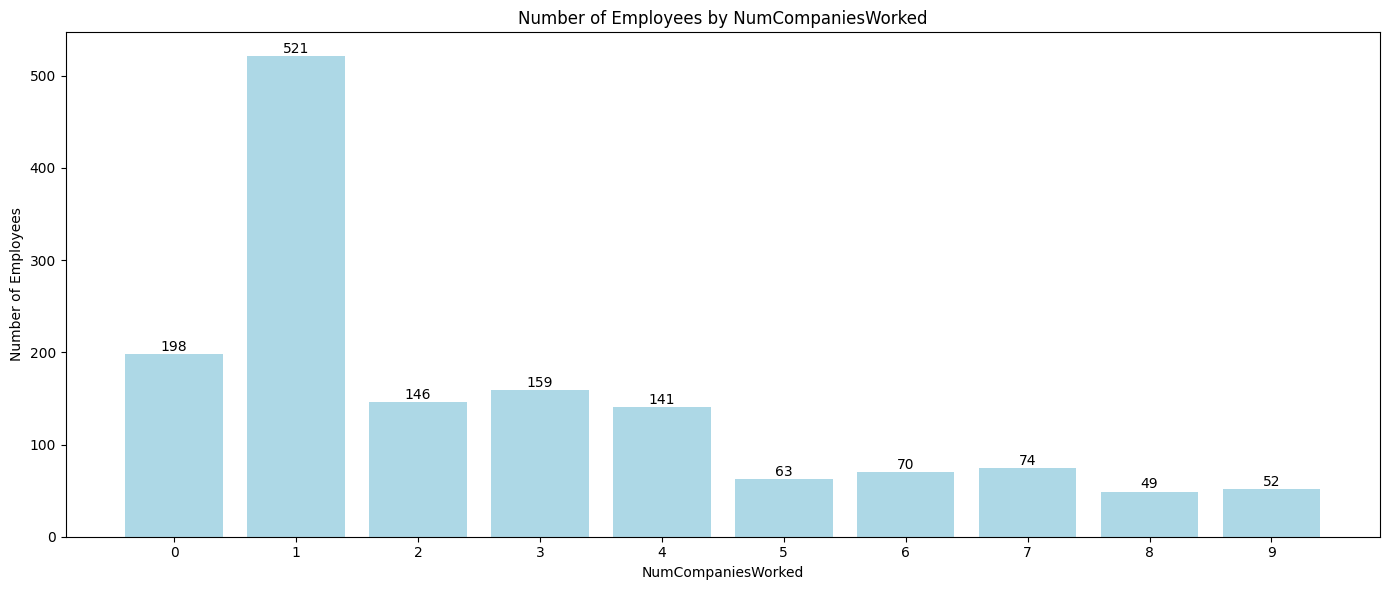

In [94]:
df_NumCompaniesWorked = df_cleaned["NumCompaniesWorked"].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(df_NumCompaniesWorked.index,df_NumCompaniesWorked.values,color="Lightblue")
plt.xlabel("NumCompaniesWorked")
plt.ylabel("Number of Employees")
plt.title("Number of Employees by NumCompaniesWorked")

# Show all NumCompaniesWorked labels
plt.xticks(df_NumCompaniesWorked.index, rotation=0)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### NumCompaniesWorked Analysis

- Most employees (**521**) have worked for only **1 company**.
- **198 employees** have not worked for any previous company.
- The number of employees decreases as the number of companies worked increases.
- Only a small number of employees have worked for **5 or more companies**.
- Overall, the workforce appears relatively stable, with most employees having experience with **0–4 companies**.

In [95]:
pd.crosstab(df_cleaned['NumCompaniesWorked'],
           df_cleaned['Attrition']).T

NumCompaniesWorked,0,1,2,3,4,5,6,7,8,9
Attrition,,,,,,,,,,
No,175,423,130,143,124,47,54,57,43,40
Yes,23,98,16,16,17,16,16,17,6,12


#### Business Insight

This helps identify whether employees with more previous job experience are more likely to leave the current company.

In [96]:
df_cleaned['PercentSalaryHike'].value_counts()

PercentSalaryHike
11    210
13    209
14    201
12    198
15    102
18     90
17     83
16     78
19     76
22     56
20     55
21     48
23     28
24     21
25     18
Name: count, dtype: int64

In [97]:
pd.crosstab(df_cleaned['PercentSalaryHike'],
           df_cleaned['Attrition']).T

PercentSalaryHike,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
Attrition,,,,,,,,,,,,,,,
No,169,165,175,177,84,64,69,77,67,48,43,44,22,15,17
Yes,41,33,34,24,18,14,14,13,9,7,5,12,6,6,1


In [98]:
df_cleaned['PerformanceRating'].value_counts()

PerformanceRating
3    1247
4     226
Name: count, dtype: int64

In [99]:
pd.crosstab(df_cleaned['PerformanceRating'],
           df_cleaned['Attrition']).T

PerformanceRating,3,4
Attrition,,
No,1047,189
Yes,200,37


In [100]:
df_cleaned['RelationshipSatisfaction'].value_counts()

RelationshipSatisfaction
3    460
4    433
2    303
1    277
Name: count, dtype: int64

In [101]:
df_cleaned['StockOptionLevel'].value_counts()

StockOptionLevel
0    632
1    598
2    158
3     85
Name: count, dtype: int64

In [102]:
pd.crosstab(
    df_cleaned['TotalWorkingYears'],
    df_cleaned['Attrition'],
    margins=True,
    margins_name='Total'
)

Attrition,No,Yes,Total
TotalWorkingYears,,,
0,6,5,11
1,41,40,81
2,22,9,31
3,33,9,42
4,51,12,63
5,73,16,89
6,103,22,125
7,63,18,81
8,87,16,103


In [103]:
df_cleaned['TrainingTimesLastYear'].value_counts()

TrainingTimesLastYear
2    548
3    492
4    123
5    120
1     71
6     65
0     54
Name: count, dtype: int64

In [104]:
pd.crosstab(df_cleaned['TrainingTimesLastYear'],
           df_cleaned['Attrition']).T

TrainingTimesLastYear,0,1,2,3,4,5,6
Attrition,,,,,,,
No,39,62,450,423,97,106,59
Yes,15,9,98,69,26,14,6


In [105]:
df_cleaned['WorkLifeBalance'].value_counts()

WorkLifeBalance
3    896
2    344
4    153
1     80
Name: count, dtype: int64

In [106]:
pd.crosstab(df_cleaned['WorkLifeBalance'],
           df_cleaned['Attrition']).T

WorkLifeBalance,1,2,3,4
Attrition,,,,
No,55,286,769,126
Yes,25,58,127,27


In [107]:
pd.crosstab(df_cleaned['YearsAtCompany'],
           df_cleaned['Attrition'])

Attrition,No,Yes
YearsAtCompany,,
0,28,16
1,112,59
2,100,27
3,108,20
4,92,19
5,176,21
6,67,9
7,80,11
8,71,9


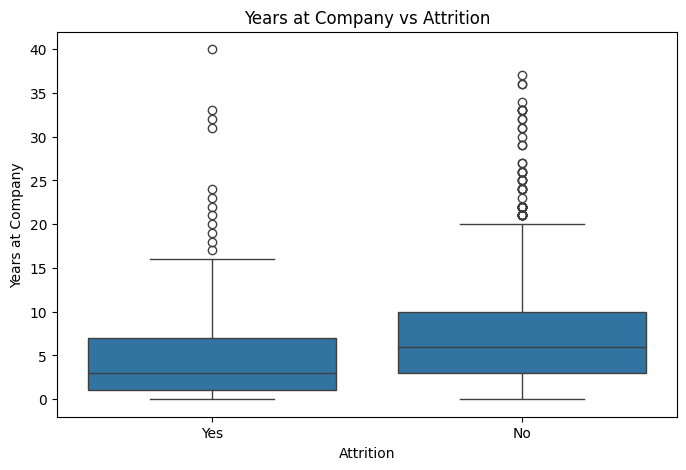

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_cleaned,
    x='Attrition',
    y='YearsAtCompany'
)

plt.title('Years at Company vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
plt.show()

In [109]:
pd.crosstab(df_cleaned['YearsInCurrentRole'],
           df_cleaned['Attrition'],
           margins=True,
    margins_name='Total')

Attrition,No,Yes,Total
YearsInCurrentRole,,,
0,171,73,244
1,46,11,57
2,306,68,374
3,119,16,135
4,89,15,104
5,35,1,36
6,35,2,37
7,192,31,223
8,82,7,89


In [110]:

pd.crosstab(df_cleaned['YearsSinceLastPromotion'],
           df_cleaned['Attrition'],
           margins=True,
    margins_name='Total')

Attrition,No,Yes,Total
YearsSinceLastPromotion,,,
0,473,110,583
1,309,49,358
2,132,27,159
3,43,9,52
4,56,5,61
5,43,2,45
6,26,6,32
7,60,16,76
8,18,0,18


In [111]:
pd.crosstab(df_cleaned['YearsWithCurrManager'],
           df_cleaned['Attrition'],
           margins=True,
    margins_name='Total')

Attrition,No,Yes,Total
YearsWithCurrManager,,,
0.0,169,83,252
1.0,65,11,76
2.0,280,49,329
3.0,169,26,195
4.0,84,10,94
5.0,27,4,31
6.0,25,4,29
7.0,180,30,210
8.0,90,9,99


## 8. Correlation Analysis

Analyze correlations between numerical variables to identify:

- Strong relationships
- Weak relationships
- Possible redundant variables
- Important factors related to employee behavior


In [112]:
# Select numerical columns
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])
# Calculate correlation
correlation = numeric_df.corr()
correlation

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.009831,-0.001441,0.207328,0.009346,0.025559,0.030303,0.509977,-0.005404,0.498078,...,0.002212,0.052204,0.038256,0.680300,-0.018831,-0.021722,0.311535,0.213357,0.216867,0.206627
DailyRate,0.009831,1.000000,-0.004936,-0.016249,0.018710,0.022450,0.045978,0.002095,0.031329,0.006887,...,0.000289,0.009106,0.041497,0.014202,0.001544,-0.037684,-0.034384,0.009217,-0.033597,-0.022419
DistanceFromHome,-0.001441,-0.004936,1.000000,0.020427,-0.016472,0.030552,0.011455,0.005338,-0.001994,-0.017885,...,0.026845,0.006854,0.045349,0.005834,-0.036918,-0.026341,0.009290,0.018115,0.009566,0.014296
Education,0.207328,-0.016249,0.020427,1.000000,-0.028630,0.018839,0.042461,0.100291,-0.009961,0.094285,...,-0.023726,-0.007177,0.017881,0.147879,-0.027329,0.009191,0.069176,0.059486,0.054994,0.067072
EnvironmentSatisfaction,0.009346,0.018710,-0.016472,-0.028630,1.000000,-0.052249,-0.009575,0.001108,-0.007619,-0.006401,...,-0.030264,0.007382,0.002922,-0.003436,-0.018430,0.028193,0.001009,0.017995,0.015224,0.003932
HourlyRate,0.025559,0.022450,0.030552,0.018839,-0.052249,1.000000,0.043260,-0.027256,-0.071100,-0.014751,...,-0.000964,0.000941,0.050867,-0.001739,-0.009266,-0.005552,-0.018679,-0.023408,-0.024982,-0.001269
JobInvolvement,0.030303,0.045978,0.011455,0.042461,-0.009575,0.043260,1.000000,-0.012590,-0.019093,-0.016240,...,-0.028937,0.034784,0.022251,-0.003863,-0.015861,-0.014650,-0.021369,0.007847,-0.024226,0.037231
JobLevel,0.509977,0.002095,0.005338,0.100291,0.001108,-0.027256,-0.012590,1.000000,-0.003047,0.950134,...,-0.021156,0.019902,0.014710,0.781761,-0.016780,0.037752,0.534710,0.389918,0.353819,0.367207
JobSatisfaction,-0.005404,0.031329,-0.001994,-0.009961,-0.007619,-0.071100,-0.019093,-0.003047,1.000000,-0.008712,...,0.002342,-0.010328,0.010449,-0.019397,-0.007564,-0.019470,-0.004135,-0.003700,-0.018436,-0.030717
MonthlyIncome,0.498078,0.006887,-0.017885,0.094285,-0.006401,-0.014751,-0.016240,0.950134,-0.008712,1.000000,...,-0.016862,0.024266,0.005863,0.771929,-0.020610,0.030467,0.514343,0.364477,0.345188,0.338811


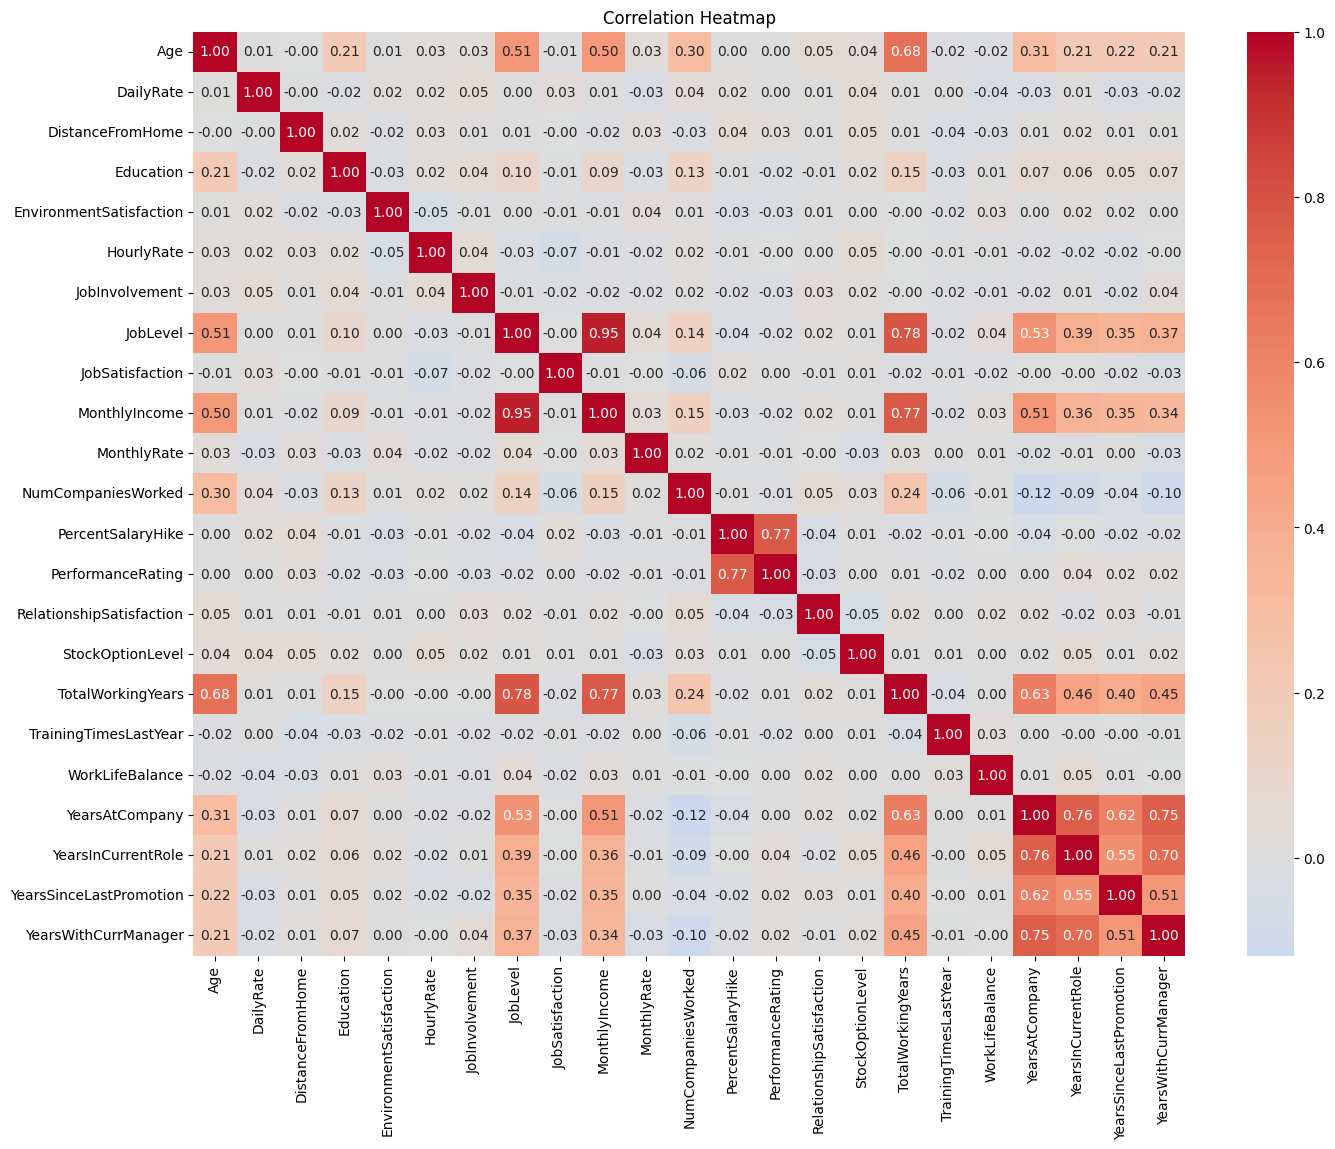

In [113]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

In [114]:
corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(10)

JobLevel            MonthlyIncome              0.950134
                    TotalWorkingYears          0.781761
PercentSalaryHike   PerformanceRating          0.772845
MonthlyIncome       TotalWorkingYears          0.771929
YearsAtCompany      YearsInCurrentRole         0.758659
                    YearsWithCurrManager       0.753753
YearsInCurrentRole  YearsWithCurrManager       0.704746
Age                 TotalWorkingYears          0.680300
TotalWorkingYears   YearsAtCompany             0.627892
YearsAtCompany      YearsSinceLastPromotion    0.618491
dtype: float64

### Correlation Analysis

Correlation analysis was performed to understand the linear relationships between numerical variables.

A correlation value ranges from **-1 to +1**:

- **+1** indicates a strong positive relationship.
- **-1** indicates a strong negative relationship.
- **0** indicates little or no linear relationship.

A correlation heatmap was used to visually identify strong and weak relationships between numerical variables.

This analysis helps identify related variables and understand the overall structure of the dataset. However, correlation does not imply causation.

### Key Findings

The correlation heatmap shows the relationships between numerical variables.

#### Strong Positive Correlations

- `MonthlyIncome` and `TotalWorkingYears` → **0.77**
- `PercentSalaryHike` and `PerformanceRating` → **0.77**
- `YearsAtCompany` and `YearsInCurrentRole` → **0.76**
- `YearsAtCompany` and `YearsWithCurrManager` → **0.75**
- `YearsInCurrentRole` and `YearsWithCurrManager` → **0.70**
- `Age` and `TotalWorkingYears` → **0.68**

#### Moderate Correlations

- `TotalWorkingYears` and `YearsAtCompany` → **0.63**
- `MonthlyIncome` and `YearsAtCompany` → **0.51**
- `Age` and `MonthlyIncome` → **0.50**

Overall, variables related to **age, experience, income, and tenure** show stronger relationships with each other. Most other numerical variables have weak correlations.

Correlation shows association between variables and does not necessarily mean that one variable causes another.



## 9. Key Business Insights

The analysis provides the following important business insights:

### 1. Employee Attrition
Employee attrition is an important concern because losing employees can increase recruitment and training costs.

### 2. Overtime
Employees working overtime may have a higher risk of leaving the organization. Excessive workload can negatively affect employee satisfaction and work-life balance.

### 3. Job Satisfaction
Employees with lower job satisfaction may be more likely to leave the organization. Improving the employee experience can support retention.

### 4. Work-Life Balance
Poor work-life balance can contribute to employee dissatisfaction and may increase the possibility of attrition.

### 5. Employee Age
Age shows relationships with experience and income. Older employees generally have more total working experience.

### 6. Monthly Income
Monthly income has a strong positive correlation with TotalWorkingYears (0.77). Employees with more experience generally tend to have higher income.

### 7. Performance Rating and Salary Hike
PerformanceRating and PercentSalaryHike have a strong positive correlation (0.77), showing a strong relationship between these two variables in the dataset.

### 8. Employee Tenure
YearsAtCompany has strong relationships with YearsInCurrentRole (0.76) and YearsWithCurrManager (0.75). Employees who stay longer tend to spend more time in their current role and with their manager.

### 9. Previous Company Experience
Most employees have worked for only one company before their current organization. Employees with experience across many companies are comparatively fewer.

### 10. Career Growth
Opportunities for promotion, role changes, and professional development can play an important role in employee retention.

### 11. Job Role
Attrition can vary across different job roles. Some roles may require more attention because of workload, salary, or career-growth differences.

### 12. Business Travel
Employees with frequent business travel may experience additional workload or work-life challenges, which can affect retention.

### 13. Job Level
Job level is related to career position and compensation. Employees at different job levels may show different attrition patterns.

### 14. Total Working Experience
TotalWorkingYears has a strong positive relationship with Age (0.68), showing that older employees generally have more overall work experience.

### 15. Employee Retention
The organization can improve retention by focusing on workload, employee satisfaction, career growth, compensation, and work-life balance.

### Overall Insight

Employee attrition is influenced by multiple factors rather than a single variable. Therefore, HR teams should use a combination of employee, job, salary, experience, and satisfaction-related factors when developing employee-retention strategies.

### Overall Business Conclusion

The analysis shows that employee retention is closely connected with factors such as overtime, job satisfaction, work-life balance, compensation, career growth, and employee tenure.

Organizations can reduce attrition by identifying high-risk employee groups and taking targeted actions such as improving workload management, providing career-growth opportunities, reviewing compensation, and improving employee satisfaction.

## 10. Business Recommendations

Based on the analysis of employee attrition and other factors, the following recommendations can help the organization improve employee retention:

### 1. Reduce Excessive Overtime
Monitor employees who frequently work overtime and improve workload distribution to reduce employee stress and burnout.

### 2. Improve Job Satisfaction
Conduct regular employee feedback surveys and identify the main reasons for low job satisfaction.

### 3. Improve Work-Life Balance
Provide flexible working options, reasonable working hours, and adequate leave to support a healthy work-life balance.

### 4. Provide Career Growth Opportunities
Create clear career paths, training programs, and promotion opportunities so employees can see long-term growth within the organization.

### 5. Review Compensation
Regularly review salaries and salary increases to ensure that compensation remains competitive and fair.

### 6. Support New Employees
Provide better onboarding, mentoring, and guidance to new employees, especially during their early years in the organization.

### 7. Focus on High-Risk Employee Groups
Use the analysis to identify employee groups with higher attrition rates and provide targeted retention strategies.

### 8. Improve Manager-Employee Relationships
Encourage managers to communicate regularly with employees and provide proper feedback and support.

### 9. Monitor Employee Satisfaction
Track job satisfaction, environment satisfaction, relationship satisfaction, and work-life balance regularly.

### 10. Use Data-Driven HR Decisions
Build an HR dashboard to continuously monitor attrition, employee satisfaction, salary, overtime, tenure, and other important factors.

### Overall Recommendation

The organization should focus on a combination of **workload management, employee satisfaction, career growth, fair compensation, and work-life balance** to reduce employee attrition and improve employee retention.

## 11. Conclusion

- This Employee Attrition Analysis helped identify the major factors associated with employee attrition.
- The analysis covered data cleaning, univariate analysis, attrition analysis, categorical and numerical analysis, and correlation analysis.
- Key factors such as **overtime, job satisfaction, work-life balance, income, job role, career growth, and employee tenure** were analyzed to understand employee behavior.
- The findings can help organizations identify employees who may be at higher risk of leaving and develop better retention strategies.

- Overall, a **data-driven approach** can help HR teams improve employee satisfaction, reduce attrition, and retain valuable employees.